**Big Data-Driven Solar PV Forecasting in Saudi Arabia: A Hybrid CNN-LSTM-Transformer Benchmark**

## Turn 1 — EDA

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Upload dataset file from local machine
from google.colab import files

uploaded = files.upload()

Saving KSAsolar2024.csv to KSAsolar2024 (1).csv


In [ ]:
df = pd.read_csv("/content/KSAsolar2024.csv", encoding='latin1')

df.head()

,Date,City,Latitude,Longitude,Temperature (°C),Weather,Panel Type,Mount Type,Tilt (°),Panel Efficiency (%),Solar Irradiance (kWh/m²/day),Output Power (W),Estimated Daily Output (kWh)
0,1/1/2024,Riyadh,24.7136,46.6753,18,few clouds,Monocrystalline,Rooftop,25,22,5.39,1.90,21.06
1,1/1/2024,Riyadh,24.7136,46.6753,18,few clouds,Polycrystalline,Rooftop,25,18,5.39,1.55,21.06
2,1/1/2024,Riyadh,24.7136,46.6753,18,few clouds,Thin-Film,Rooftop,25,12,5.39,1.04,21.06
3,1/1/2024,Riyadh,24.7136,46.6753,18,few clouds,Monocrystalline,Ground,15,22,4.97,1.75,19.47
4,1/1/2024,Riyadh,24.7136,46.6753,18,few clouds,Polycrystalline,Ground,15,18,4.97,1.43,19.47


### PySpark — Big Data Ingestion Layer
Designed to scale to national-grid sensor streams.

In [ ]:
# ── PySpark Big Data Layer ──────
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','pyspark','-q'], capture_output=True)

from pyspark.sql import SparkSession
import re

def spark_clean(c):
    """Make column names SQL-safe: replace unicode special chars first."""
    c = c.strip()
    c = c.replace('\u00b2','2').replace('\u00b0','deg').replace('%','pct')
    c = re.sub(r'[\s/]+','_', c)
    c = re.sub(r'[^\w]','', c)
    return c

spark = (SparkSession.builder
    .appName('KSA_Solar_BigData_2024')
    .config('spark.driver.memory','4g')
    .config('spark.sql.shuffle.partitions','8')
    .getOrCreate())
spark.sparkContext.setLogLevel('ERROR')
print(f'Spark {spark.version} ready.')

sdf = (spark.read
    .option('header','true').option('inferSchema','true')
    .option('encoding','ISO-8859-1')
    .csv('/content/KSAsolar2024.csv'))

for old in sdf.columns:
    new = spark_clean(old)
    if old != new:
        sdf = sdf.withColumnRenamed(old, new)

print(f'Shape: {sdf.count()} rows x {len(sdf.columns)} cols')
print('Cleaned columns:', sdf.columns)
sdf.createOrReplaceTempView('solar')

print('\n── City aggregation ──')
spark.sql("""SELECT City, COUNT(*) AS n,
    ROUND(AVG(Estimated_Daily_Output_kWh),3) AS avg_kWh,
    ROUND(STDDEV(Estimated_Daily_Output_kWh),3) AS std_kWh,
    ROUND(AVG(Temperature_degC),2) AS avg_temp_C,
    ROUND(AVG(Solar_Irradiance_kWh_m2_day),3) AS avg_irradiance
    FROM solar GROUP BY City ORDER BY avg_kWh DESC""").show()

print('── Panel type aggregation ──')
spark.sql("""SELECT Panel_Type,
    ROUND(AVG(Estimated_Daily_Output_kWh),4) AS avg_kWh,
    ROUND(STDDEV(Estimated_Daily_Output_kWh),4) AS std_kWh,
    COUNT(*) AS n FROM solar GROUP BY Panel_Type""").show()

print('── Weather x City aggregation ──')
spark.sql("""SELECT City, Weather,
    ROUND(AVG(Estimated_Daily_Output_kWh),3) AS avg_kWh,
    COUNT(*) AS n FROM solar GROUP BY City,Weather ORDER BY City,avg_kWh DESC""").show(20)

print('── Mount type aggregation ──')
spark.sql("""SELECT Mount_Type,
    ROUND(AVG(Estimated_Daily_Output_kWh),4) AS avg_kWh, COUNT(*) AS n
    FROM solar GROUP BY Mount_Type""").show()

spark.stop()
print('Spark complete. Handing off to pandas.')

Spark 4.0.2 ready.
Shape: 10980 rows x 13 cols
Cleaned columns: ['Date', 'City', 'Latitude', 'Longitude', 'Temperature_degC', 'Weather', 'Panel_Type', 'Mount_Type', 'Tilt_deg', 'Panel_Efficiency_pct', 'Solar_Irradiance_kWh_m2_day', 'Output_Power_W', 'Estimated_Daily_Output_kWh']

── City aggregation ──
+------+----+-------+-------+----------+--------------+
|  City|   n|avg_kWh|std_kWh|avg_temp_C|avg_irradiance|
+------+----+-------+-------+----------+--------------+
|Medina|2196|  24.96|  1.954|     30.78|         6.799|
|Riyadh|2196| 24.153|  2.209|     30.78|         6.535|
|Jeddah|2196| 24.149|  1.762|     30.78|         6.531|
| Mecca|2196| 23.987|  1.787|     30.78|         6.531|
|Dammam|2196| 22.962|  3.159|     30.78|         6.153|
+------+----+-------+-------+----------+--------------+

── Panel type aggregation ──
+---------------+-------+-------+----+
|     Panel_Type|avg_kWh|std_kWh|   n|
+---------------+-------+-------+----+
|Polycrystalline|24.0423| 2.3241|3660|
|Monoc

In [ ]:
# ---------- Column Cleaning ----------
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ","_")
    .str.replace("(","")
    .str.replace(")","")
    .str.replace("/","_")
)

df['Date']=pd.to_datetime(df['Date'])

In [ ]:
print(df.columns)

Index(['Date', 'City', 'Latitude', 'Longitude', 'Temperature_°C', 'Weather',
       'Panel_Type', 'Mount_Type', 'Tilt_°', 'Panel_Efficiency_%',
       'Solar_Irradiance_kWh_m²_day', 'Output_Power_W',
       'Estimated_Daily_Output_kWh'],
      dtype='object')


In [ ]:
# ---------- Time Features ----------
df['Month']=df['Date'].dt.month
df['DayOfYear']=df['Date'].dt.dayofyear

df['Month_sin']=np.sin(
    2*np.pi*df['Month']/12
)

df['Month_cos']=np.cos(
    2*np.pi*df['Month']/12
)

In [ ]:
# ---------- Data Profiling ----------

print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(10980, 17)

Missing Values:
Date                           0
City                           0
Latitude                       0
Longitude                      0
Temperature_°C                 0
Weather                        0
Panel_Type                     0
Mount_Type                     0
Tilt_°                         0
Panel_Efficiency_%             0
Solar_Irradiance_kWh_m²_day    0
Output_Power_W                 0
Estimated_Daily_Output_kWh     0
Month                          0
DayOfYear                      0
Month_sin                      0
Month_cos                      0
dtype: int64

Duplicate Rows:
0

Data Types:
Date                           datetime64[ns]
City                                   object
Latitude                              float64
Longitude                             float64
Temperature_°C                          int64
Weather                                object
Panel_Type                             object
Mount_Type                  

In [ ]:
# ---------- Category Distribution ----------

categorical_cols=[
    'City',
    'Weather',
    'Panel_Type',
    'Mount_Type'
]

for col in categorical_cols:

    print(f"\n{col}")

    print(
        df[col].value_counts(normalize=True)*100
    )


City
City
Riyadh    20.0
Jeddah    20.0
Mecca     20.0
Medina    20.0
Dammam    20.0
Name: proportion, dtype: float64

Weather
Weather
few clouds          25.136612
sunny               25.136612
clear sky           25.136612
scattered clouds    24.590164
Name: proportion, dtype: float64

Panel_Type
Panel_Type
Monocrystalline    33.333333
Polycrystalline    33.333333
Thin-Film          33.333333
Name: proportion, dtype: float64

Mount_Type
Mount_Type
Rooftop    50.0
Ground     50.0
Name: proportion, dtype: float64


In [ ]:
missing_pct=(
    df.isnull().mean()*100
).sort_values(ascending=False)

print(missing_pct)

Date                           0.0
City                           0.0
Latitude                       0.0
Longitude                      0.0
Temperature_°C                 0.0
Weather                        0.0
Panel_Type                     0.0
Mount_Type                     0.0
Tilt_°                         0.0
Panel_Efficiency_%             0.0
Solar_Irradiance_kWh_m²_day    0.0
Output_Power_W                 0.0
Estimated_Daily_Output_kWh     0.0
Month                          0.0
DayOfYear                      0.0
Month_sin                      0.0
Month_cos                      0.0
dtype: float64


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
# ---------- Feature Engineering ----------

df['Temp_High']=(
    df['Temperature_°C']>38
).astype(int)

df['Temp_x_Irradiance']=(
    df['Temperature_°C']
    *
    df['Solar_Irradiance_kWh_m²_day']
)

In [ ]:
# ---------- Unique Values ----------
print("\nUnique Values Per Column:\n")

for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


Unique Values Per Column:

Date: 366
City: 5
Latitude: 5
Longitude: 5
Temperature_°C: 11
Weather: 4
Panel_Type: 3
Mount_Type: 2
Tilt_°: 2
Panel_Efficiency_%: 3
Solar_Irradiance_kWh_m²_day: 95
Output_Power_W: 142
Estimated_Daily_Output_kWh: 113
Month: 12
DayOfYear: 366
Month_sin: 11
Month_cos: 11
Temp_High: 2
Temp_x_Irradiance: 117


In [ ]:
# ---------- Outlier Detection ----------

numeric=df.select_dtypes(include=np.number)

Q1=numeric.quantile(0.25)
Q3=numeric.quantile(0.75)

IQR=Q3-Q1

outliers=((numeric<(Q1-1.5*IQR)) |
          (numeric>(Q3+1.5*IQR)))

print(
outliers.sum()
)

Latitude                         0
Longitude                        0
Temperature_°C                   0
Tilt_°                           0
Panel_Efficiency_%               0
Solar_Irradiance_kWh_m²_day    186
Output_Power_W                   0
Estimated_Daily_Output_kWh     276
Month                            0
DayOfYear                        0
Month_sin                        0
Month_cos                        0
Temp_High                        0
Temp_x_Irradiance                0
dtype: int64


In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,10980,2024-07-01 12:00:00,2024-01-01 00:00:00,2024-04-01 00:00:00,2024-07-01 12:00:00,2024-10-01 00:00:00,2024-12-31 00:00:00,NaN
Latitude,10980.0,23.70678,21.3891,21.4858,24.5247,24.7136,26.4207,1.967445
Longitude,10980.0,43.07674,39.1925,39.5692,39.8579,46.6753,50.0888,4.469425
Temperature_°C,10980.0,30.778689,18.0,25.0,32.0,40.0,43.0,8.5924
Tilt_°,10980.0,20.0,15.0,15.0,20.0,25.0,25.0,5.000228
Panel_Efficiency_%,10980.0,17.333333,12.0,12.0,18.0,22.0,22.0,4.109796
Solar_Irradiance_kWh_m²_day,10980.0,6.509765,4.37,6.0775,6.73,7.09,7.59,0.74083
Output_Power_W,10980.0,1.805381,0.84,1.36,1.88,2.16,2.67,0.47708
Estimated_Daily_Output_kWh,10980.0,24.042257,17.15,22.86,24.57,25.76,27.92,2.323917
Month,10980.0,6.513661,1.0,4.0,7.0,10.0,12.0,3.451391


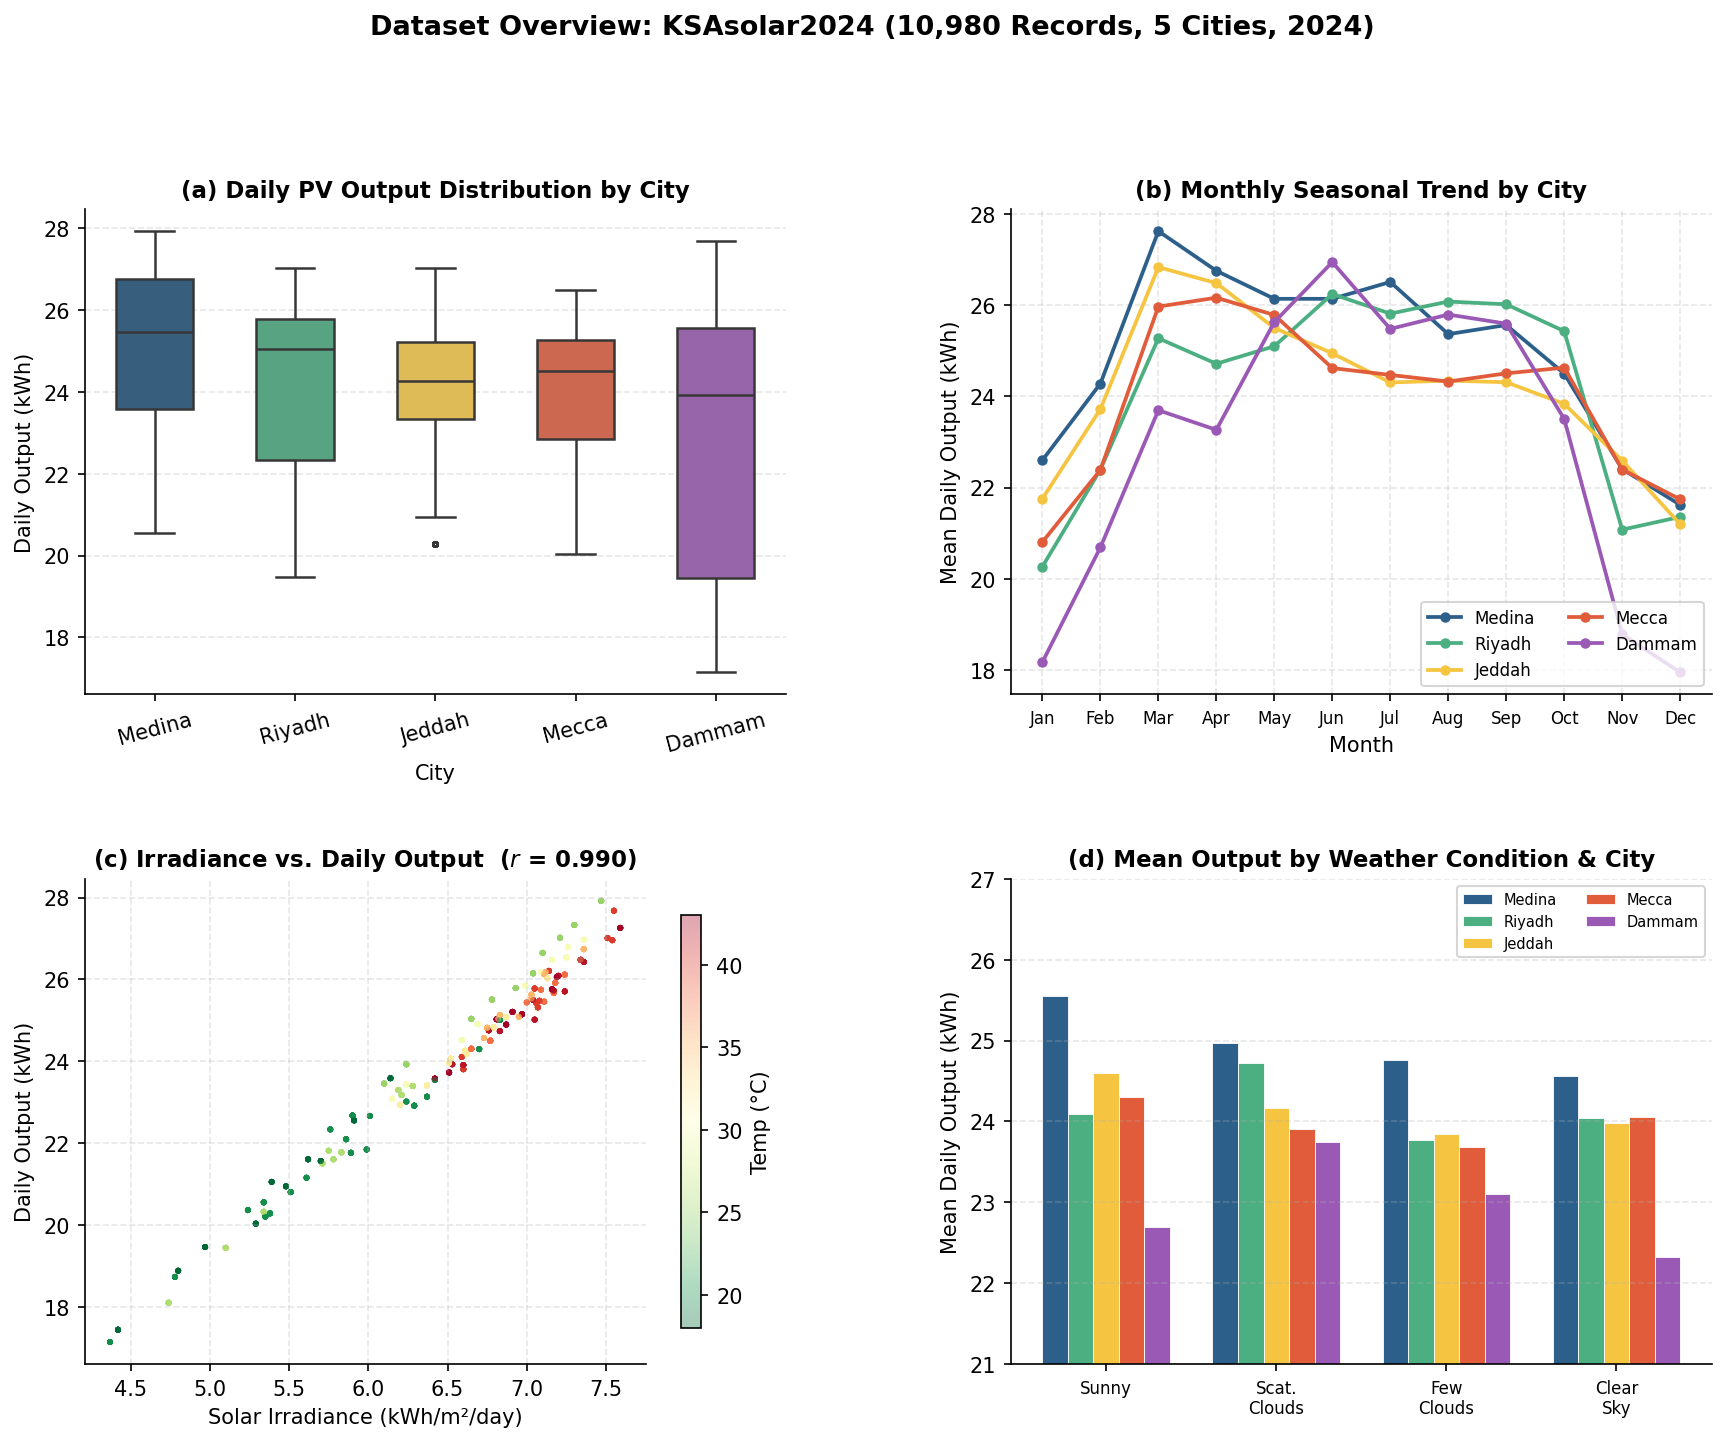

Saved: fig0_eda_overview.png


In [ ]:
# Saves: fig0_eda_overview.png
# Add this cell immediately after the team's EDA cells (after cell 35)

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'figure.dpi': 150,
    'savefig.dpi': 300, 'savefig.bbox': 'tight'
})

city_order   = ['Medina', 'Riyadh', 'Jeddah', 'Mecca', 'Dammam']
city_palette = ['#2C5F8A','#4CAF82','#F5C542','#E05C3A','#9B59B6']

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# ── (a) Box plot: daily output by city ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(
    data=df, x='City', y='Estimated_Daily_Output_kWh',
    order=city_order, palette=city_palette,
    width=0.55, linewidth=1.2, fliersize=2, ax=ax1
)
ax1.set_xlabel('City')
ax1.set_ylabel('Daily Output (kWh)')
ax1.set_title('(a) Daily PV Output Distribution by City')
ax1.spines[['top','right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(axis='x', rotation=15)

# ── (b) Monthly mean output ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
monthly = (df.groupby(['Month', 'City'])['Estimated_Daily_Output_kWh']
             .mean().reset_index())
for city, col in zip(city_order, city_palette):
    sub = monthly[monthly['City'] == city].sort_values('Month')
    ax2.plot(sub['Month'], sub['Estimated_Daily_Output_kWh'],
             marker='o', markersize=4, color=col, linewidth=1.8, label=city)
ax2.set_xlabel('Month')
ax2.set_ylabel('Mean Daily Output (kWh)')
ax2.set_title('(b) Monthly Seasonal Trend by City')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=8)
ax2.legend(fontsize=8, loc='lower right', ncol=2)
ax2.spines[['top','right']].set_visible(False)
ax2.grid(alpha=0.3, linestyle='--')

# ── (c) Irradiance vs daily output scatter ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
sample = df.sample(min(3000, len(df)), random_state=42)
sc = ax3.scatter(
    sample['Solar_Irradiance_kWh_m²_day'],
    sample['Estimated_Daily_Output_kWh'],
    c=sample['Temperature_°C'], cmap='RdYlGn_r',
    alpha=0.35, s=8, edgecolors='none'
)
plt.colorbar(sc, ax=ax3, label='Temp (°C)', shrink=0.85)
r = df['Solar_Irradiance_kWh_m²_day'].corr(df['Estimated_Daily_Output_kWh'])
ax3.set_xlabel('Solar Irradiance (kWh/m²/day)')
ax3.set_ylabel('Daily Output (kWh)')
ax3.set_title(f'(c) Irradiance vs. Daily Output  ($r$ = {r:.3f})')
ax3.spines[['top','right']].set_visible(False)
ax3.grid(alpha=0.3, linestyle='--')

# ── (d) Mean output by weather condition × city ──────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
weather_order = ['sunny', 'scattered clouds', 'few clouds', 'clear sky']
weather_city = (df.groupby(['Weather', 'City'])['Estimated_Daily_Output_kWh']
                  .mean().reset_index())
x      = np.arange(len(weather_order))
width  = 0.15
for j, (city, col) in enumerate(zip(city_order, city_palette)):
    sub = (weather_city[weather_city['City'] == city]
           .set_index('Weather')['Estimated_Daily_Output_kWh'])
    vals = [sub.get(w, np.nan) for w in weather_order]
    ax4.bar(x + j*width, vals, width, label=city, color=col,
            edgecolor='white', linewidth=0.4)
ax4.set_xticks(x + width*2)
ax4.set_xticklabels(['Sunny','Scat.\nClouds','Few\nClouds','Clear\nSky'],
                    fontsize=8)
ax4.set_ylabel('Mean Daily Output (kWh)')
ax4.set_title('(d) Mean Output by Weather Condition & City')
ax4.legend(fontsize=7, loc='upper right', ncol=2)
ax4.spines[['top','right']].set_visible(False)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
ax4.set_ylim(21, 27)

fig.suptitle(
    'Dataset Overview: KSAsolar2024 (10,980 Records, 5 Cities, 2024)',
    fontsize=13, fontweight='bold', y=1.01
)

plt.savefig('fig0_eda_overview.png', bbox_inches='tight')
plt.show()
print('Saved: fig0_eda_overview.png')

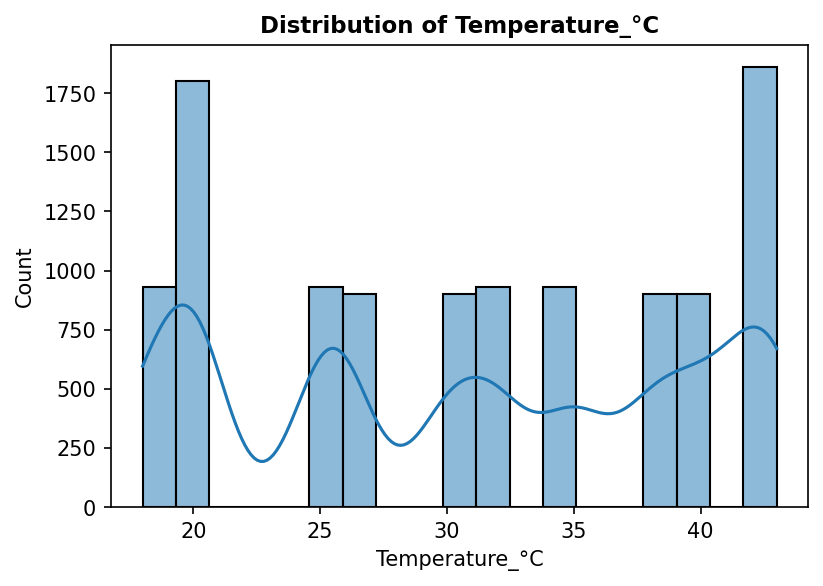

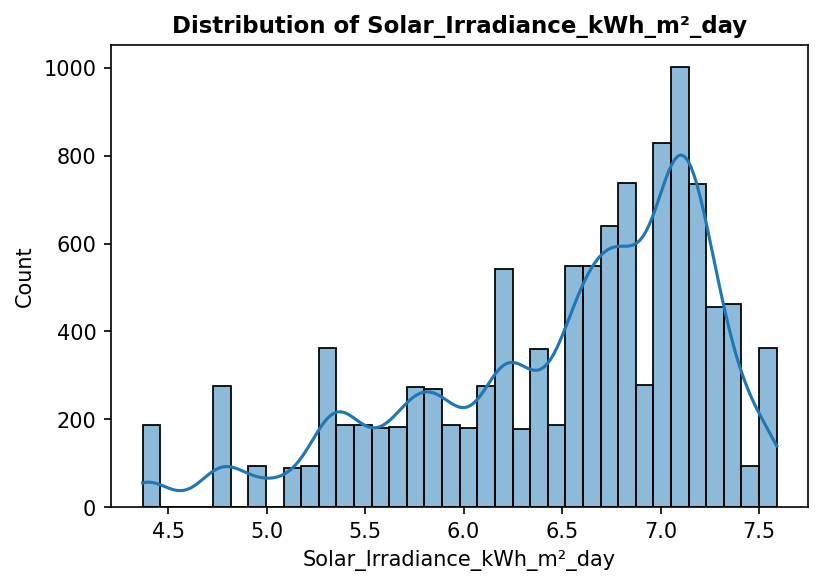

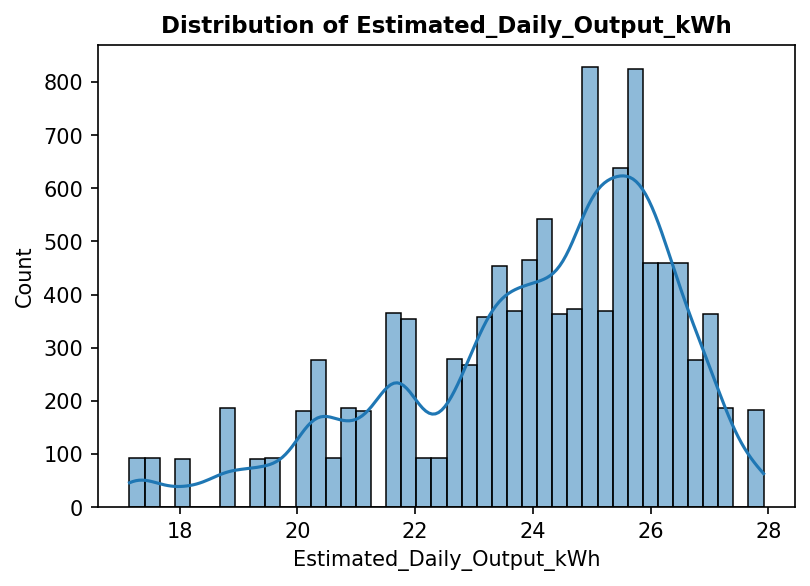

In [ ]:
# ---------- Distribution Analysis ----------

numeric_cols = [
    'Temperature_°C',
    'Solar_Irradiance_kWh_m²_day',
    'Estimated_Daily_Output_kWh'
]

for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f'Distribution of {col}')

    plt.show()

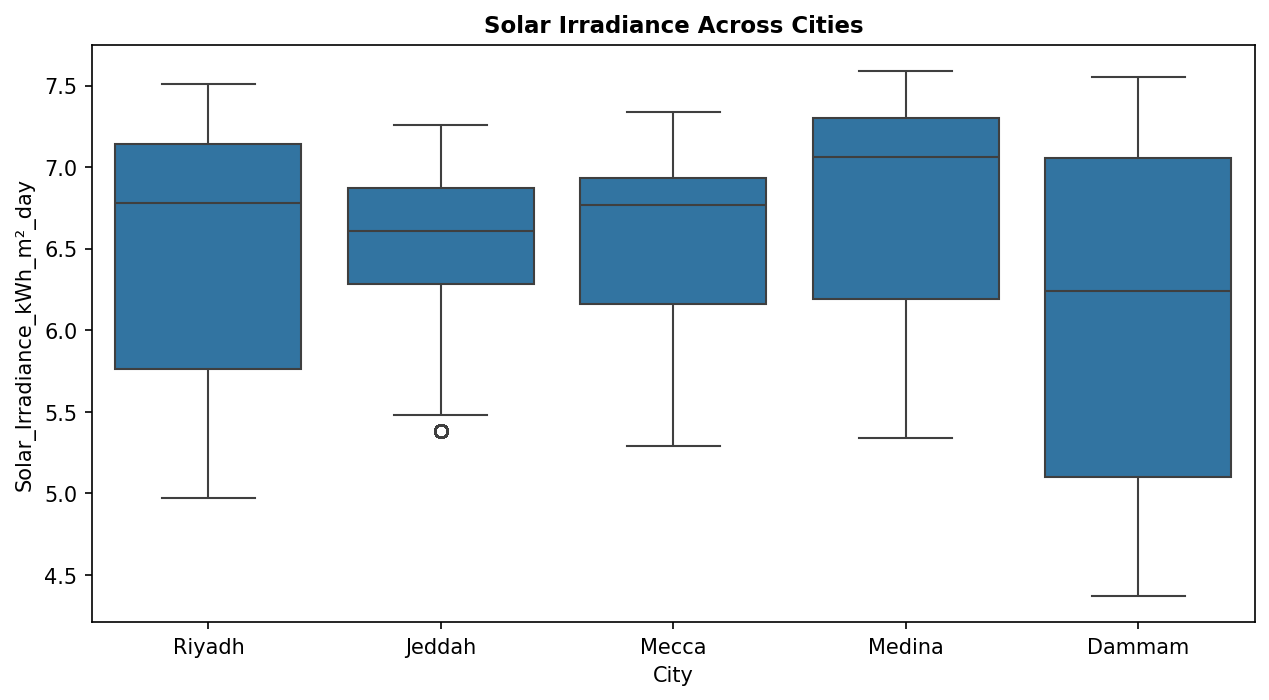

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='City',
    y='Solar_Irradiance_kWh_m²_day'
)

plt.title("Solar Irradiance Across Cities")
plt.show()

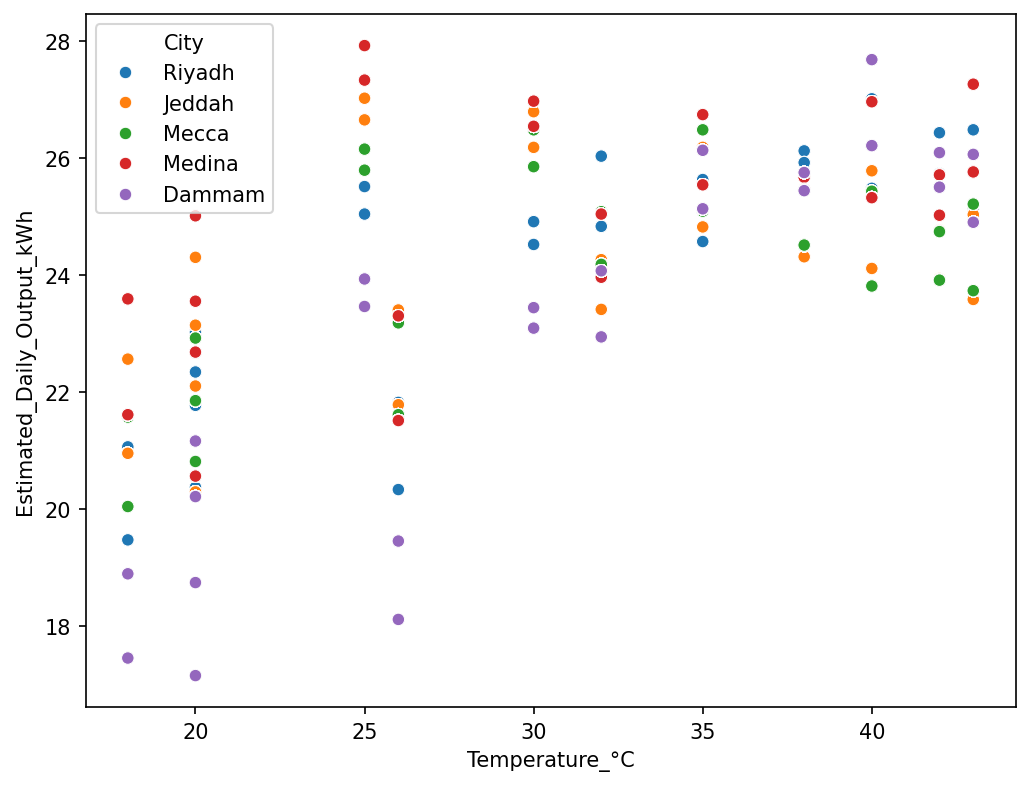

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Temperature_°C',
    y='Estimated_Daily_Output_kWh',
    hue='City'
)

plt.show()

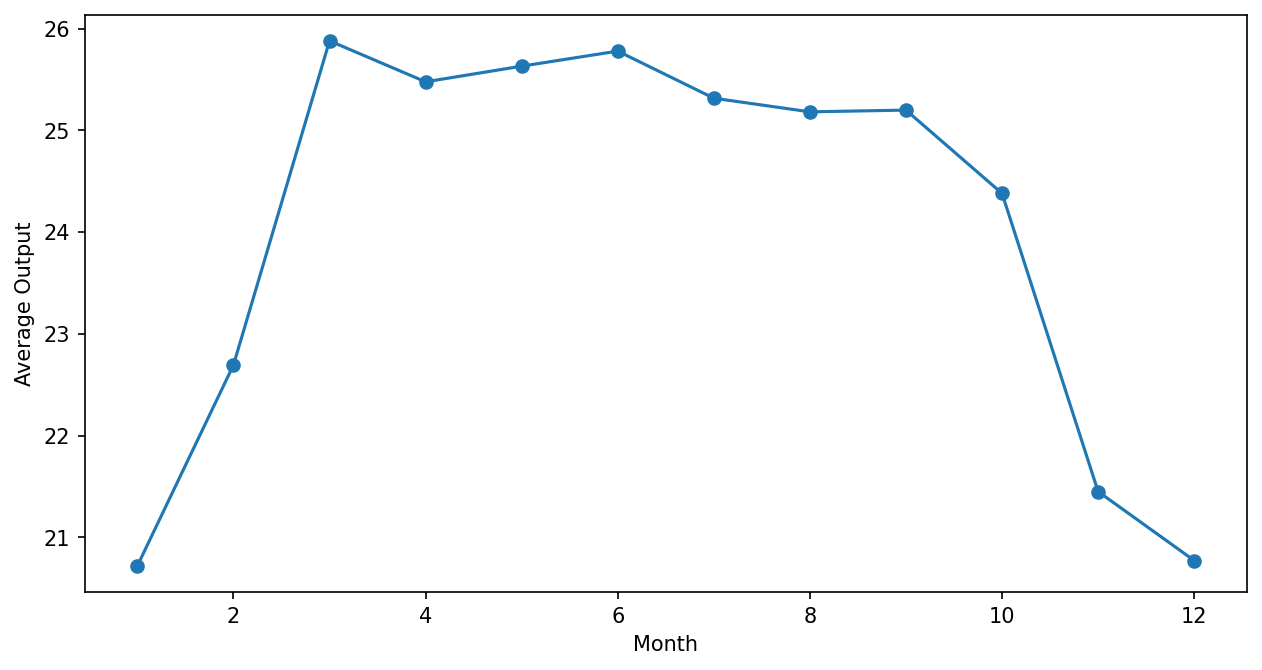

In [ ]:
monthly=df.groupby(
    'Month'
)['Estimated_Daily_Output_kWh'].mean()

monthly.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.ylabel("Average Output")
plt.show()

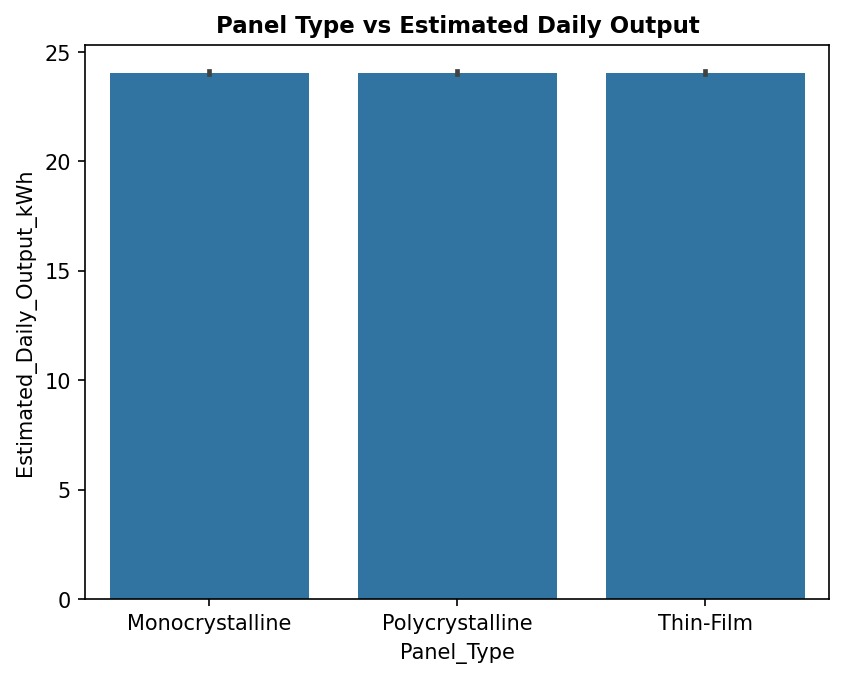

In [ ]:
sns.barplot(
    data=df,
    x='Panel_Type',
    y='Estimated_Daily_Output_kWh'
)
plt.title(
'Panel Type vs Estimated Daily Output'
)

plt.show()

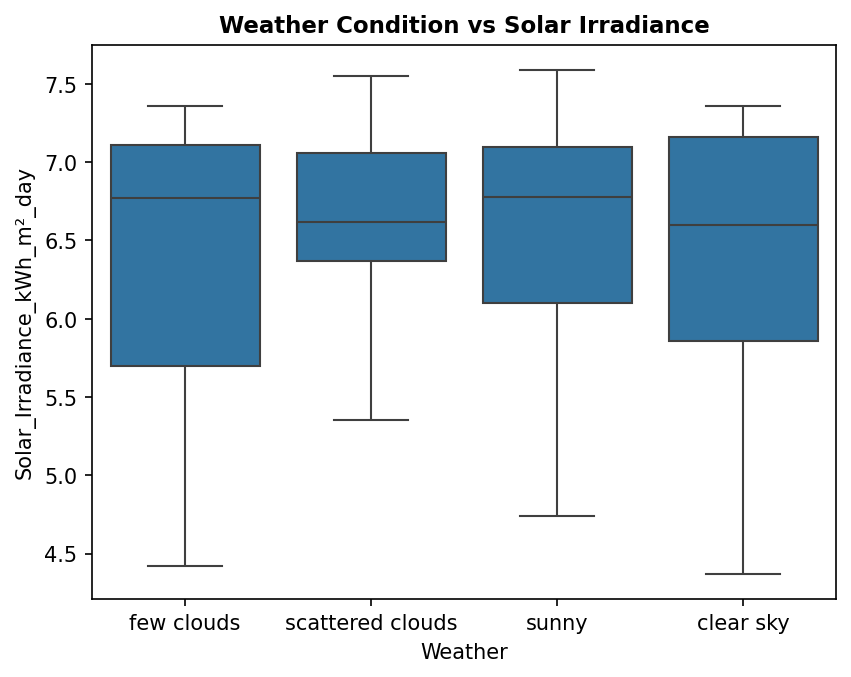

In [ ]:
sns.boxplot(
    data=df,
    x='Weather',
    y='Solar_Irradiance_kWh_m²_day'
)
plt.title(
'Weather Condition vs Solar Irradiance'
)

plt.show()

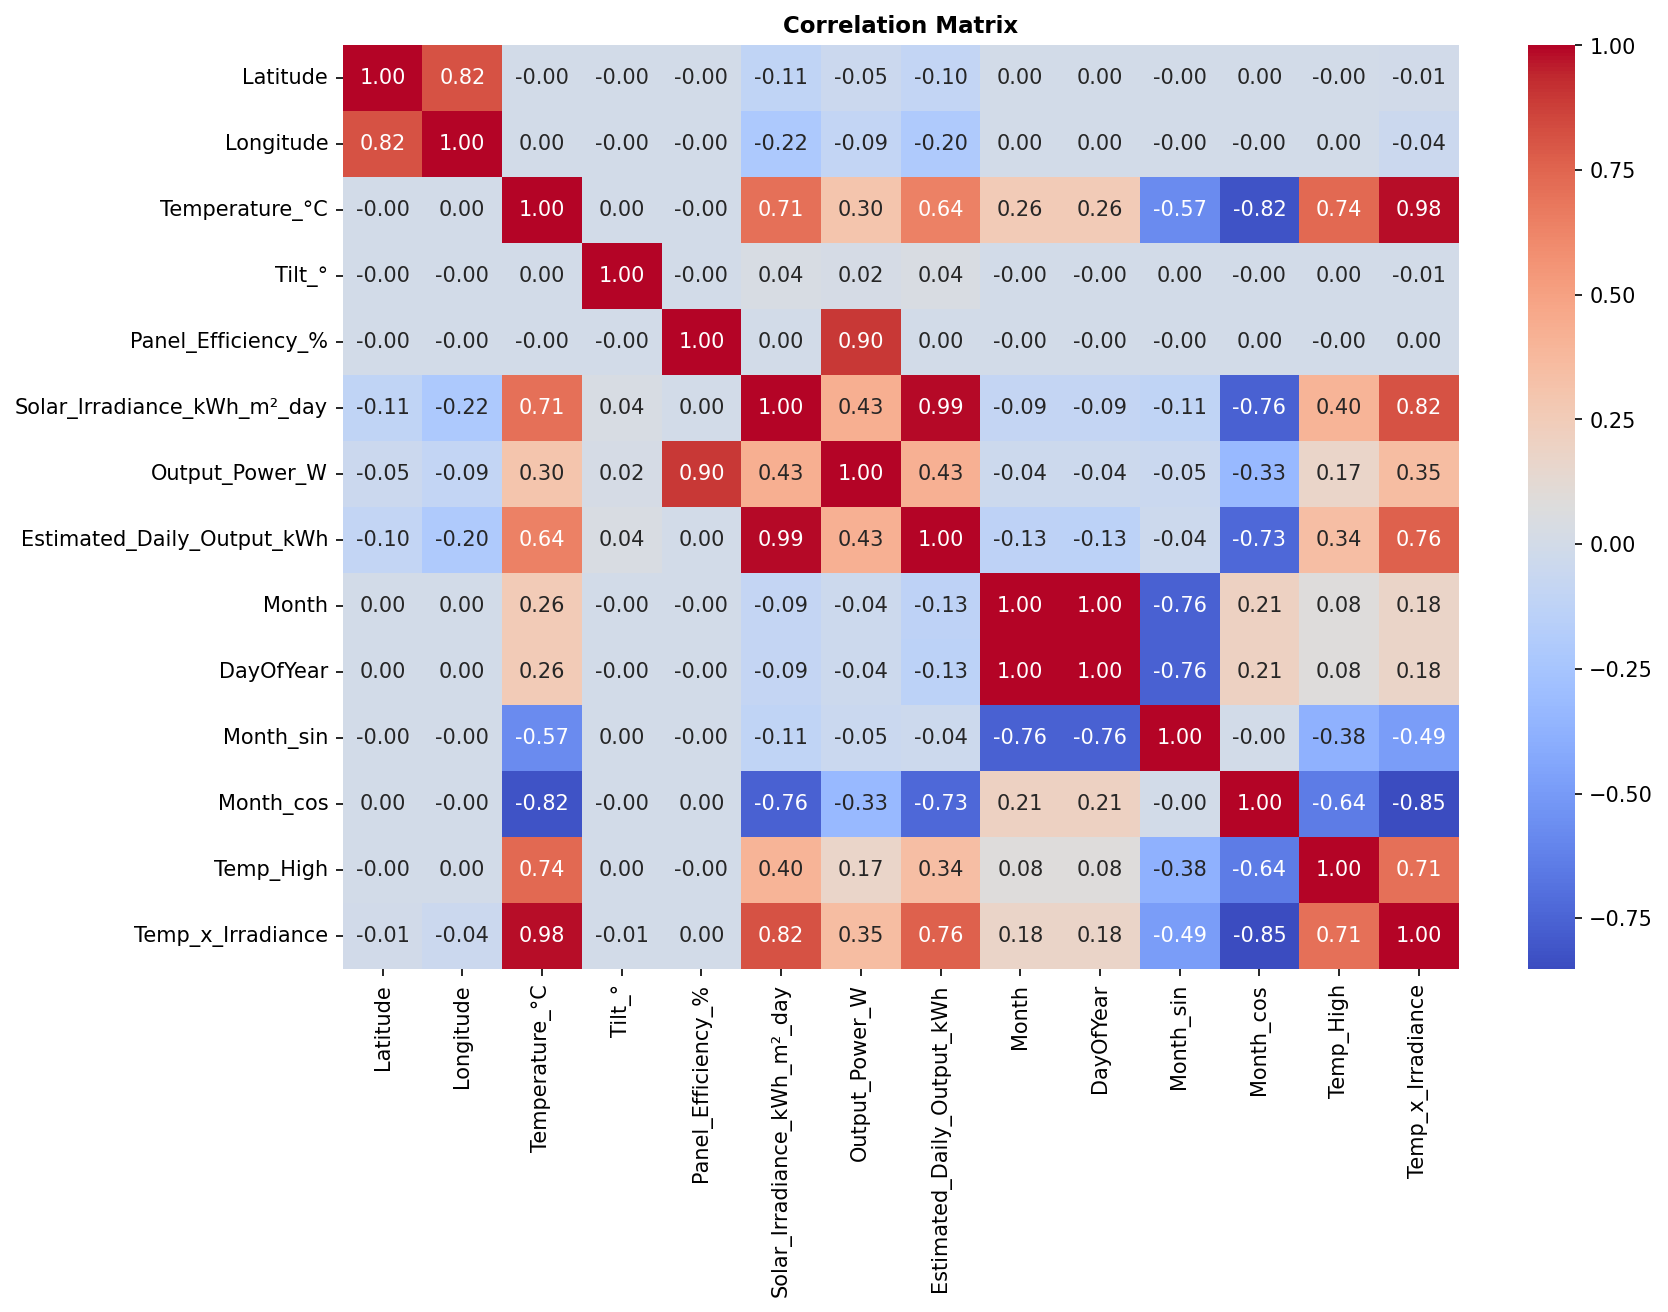

In [ ]:
numeric=df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title(
'Correlation Matrix'
)

plt.show()

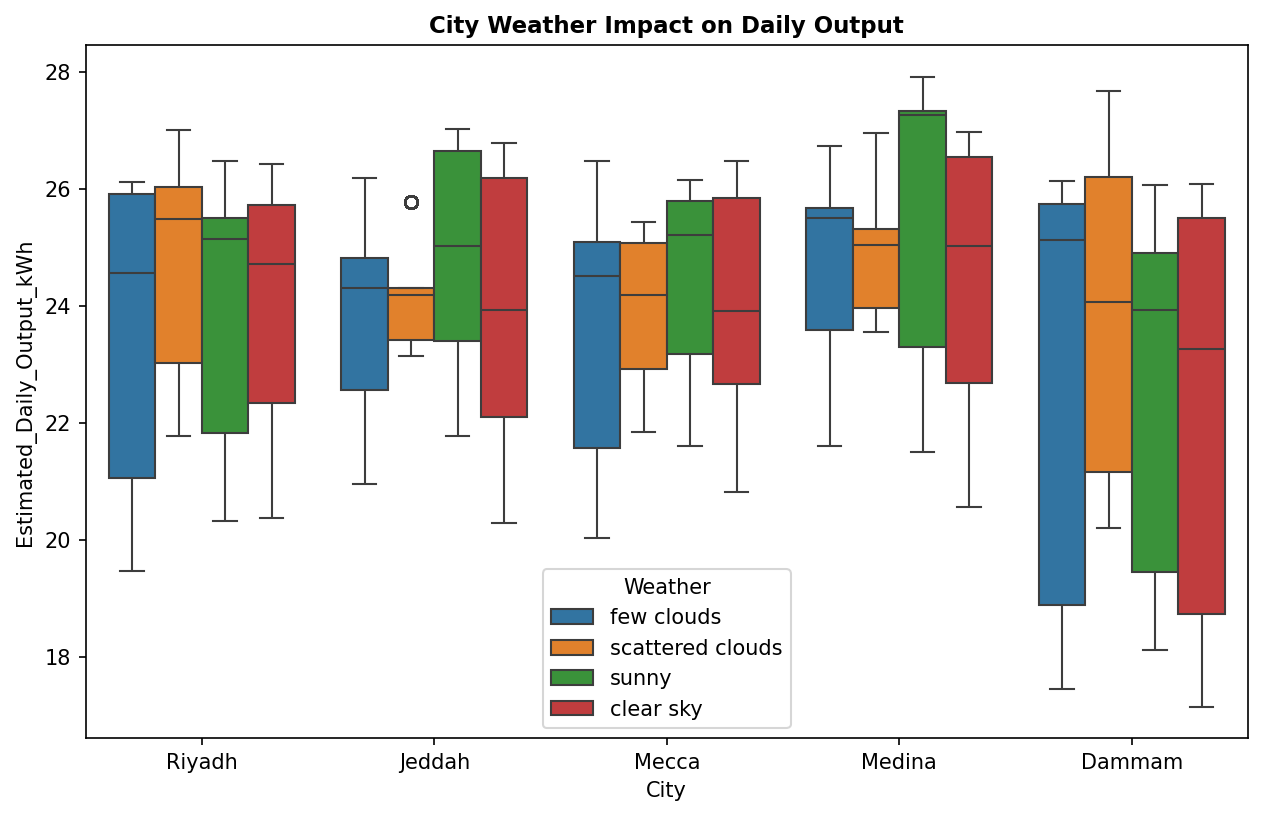

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='City',
    y='Estimated_Daily_Output_kWh',
    hue='Weather'
)

plt.title(
'City Weather Impact on Daily Output'
)

plt.show()

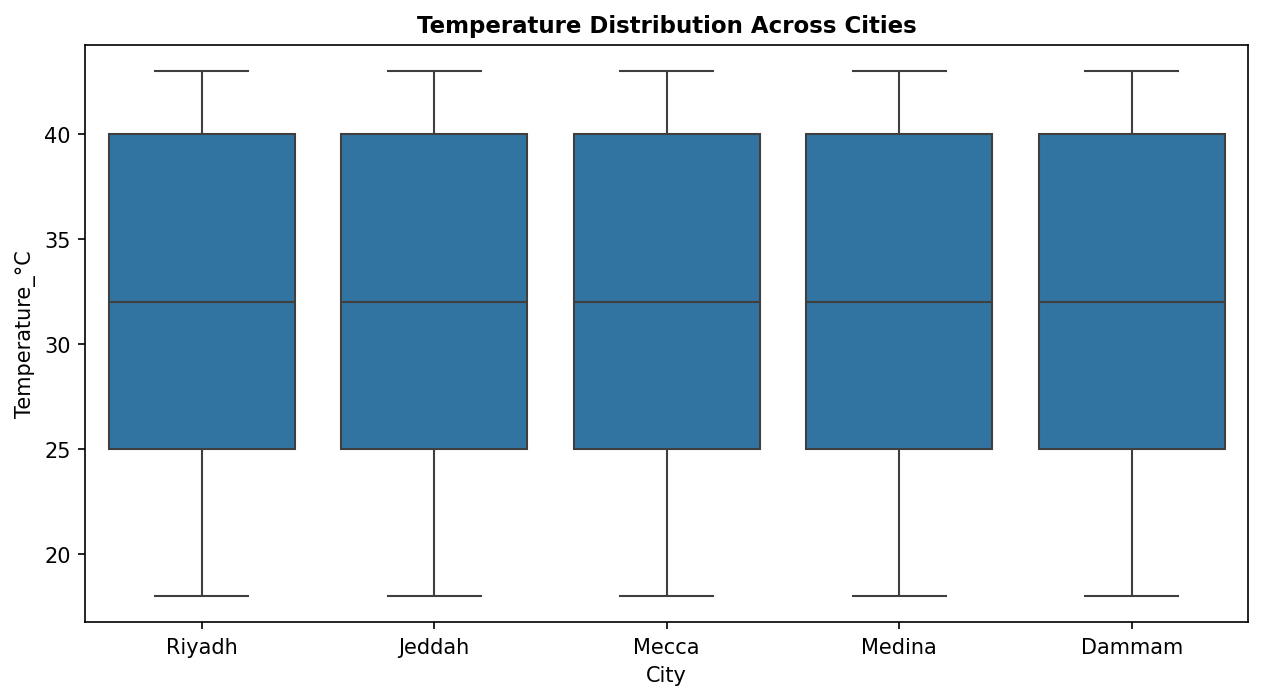

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='City',
    y='Temperature_°C'
)

plt.title(
    'Temperature Distribution Across Cities'
)

plt.show()

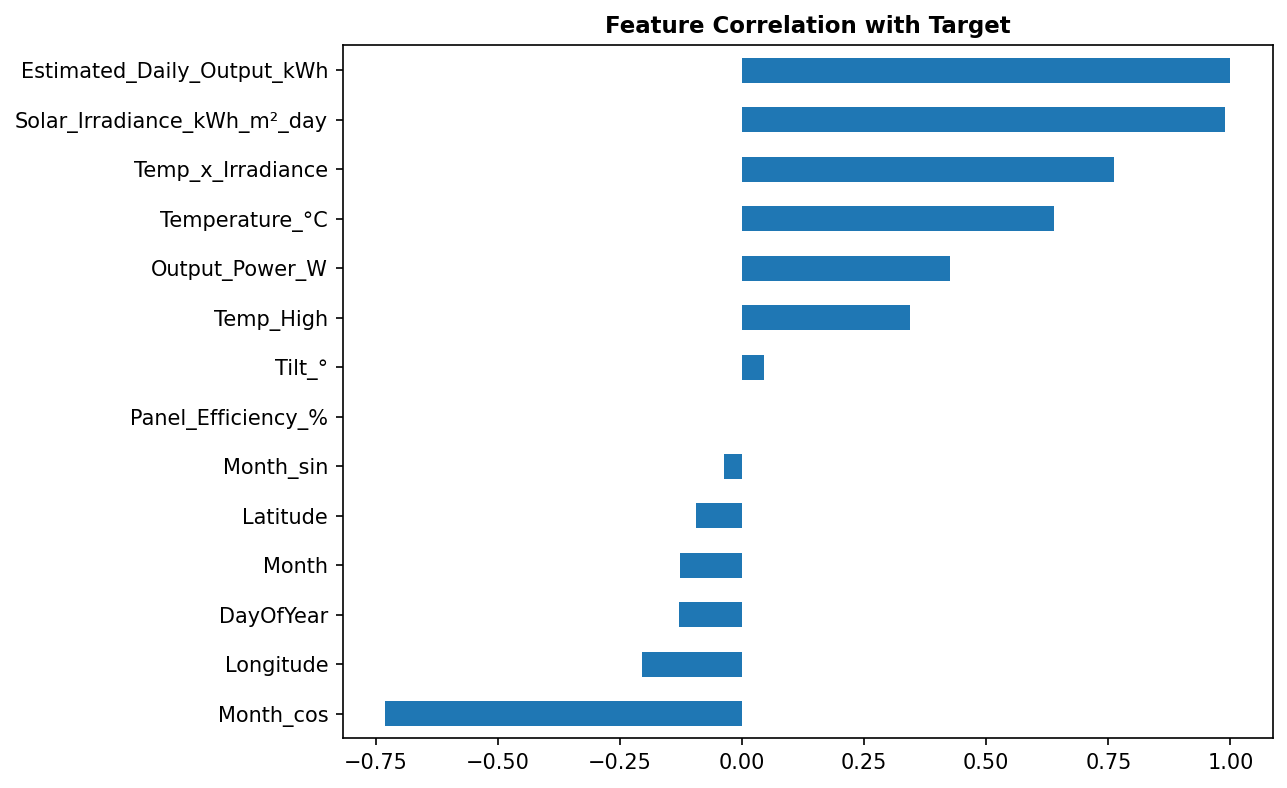

In [ ]:
# ---------- Target Correlation Analysis ----------

target_corr=numeric.corr()[
'Estimated_Daily_Output_kWh'
].sort_values()

plt.figure(figsize=(8,6))

target_corr.plot(
kind='barh'
)

plt.title(
'Feature Correlation with Target'
)

plt.show()

In [ ]:
# ---------- Top Predictive Features ----------

top_features = target_corr.abs().sort_values(
    ascending=False
)

print(
"\nMost Influential Features:"
)

print(top_features.head(10))


Most Influential Features:
Estimated_Daily_Output_kWh     1.000000
Solar_Irradiance_kWh_m²_day    0.989557
Temp_x_Irradiance              0.762094
Month_cos                      0.731404
Temperature_°C                 0.639209
Output_Power_W                 0.425398
Temp_High                      0.344002
Longitude                      0.204679
DayOfYear                      0.129510
Month                          0.128072
Name: Estimated_Daily_Output_kWh, dtype: float64


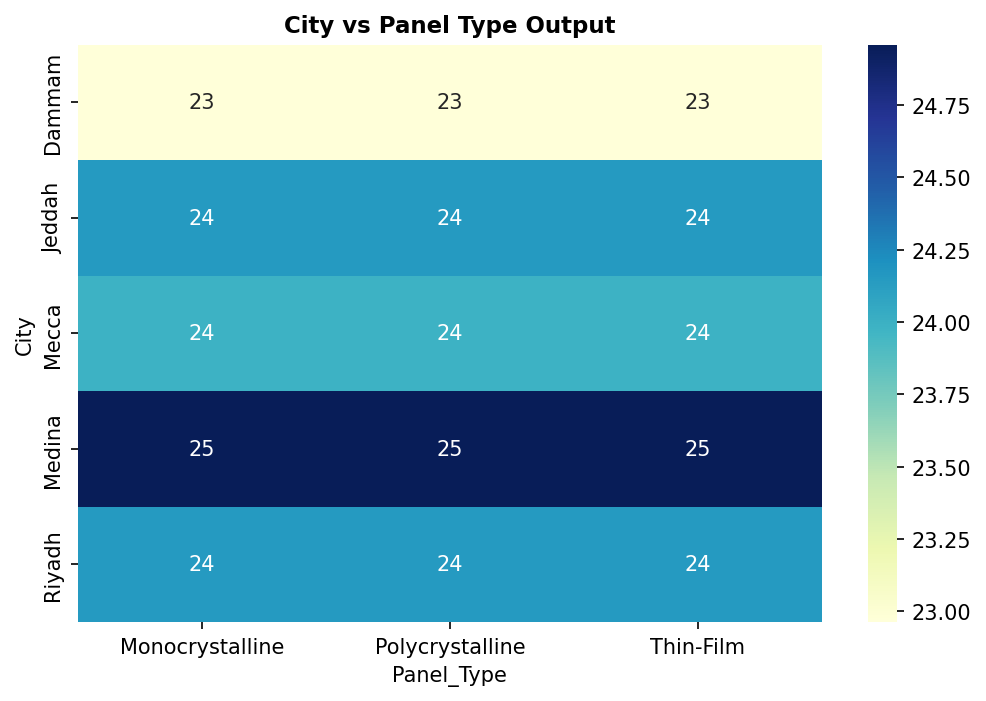

In [ ]:
pivot=df.pivot_table(
    values='Estimated_Daily_Output_kWh',
    index='City',
    columns='Panel_Type',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlGnBu'
)

plt.title(
    'City vs Panel Type Output'
)

plt.show()

In [ ]:
df.groupby(
    'Panel_Type'
)['Estimated_Daily_Output_kWh'].describe()

,count,mean,std,min,25%,50%,75%,max
Panel_Type,,,,,,,,
Monocrystalline,3660.0,24.042257,2.324129,17.15,22.86,24.57,25.76,27.92
Polycrystalline,3660.0,24.042257,2.324129,17.15,22.86,24.57,25.76,27.92
Thin-Film,3660.0,24.042257,2.324129,17.15,22.86,24.57,25.76,27.92


In [ ]:
# ---------- Panel Efficiency Validation ----------

print(

df.groupby(
'Panel_Efficiency_%'
)[
'Estimated_Daily_Output_kWh'
].mean()

)

Panel_Efficiency_%
12    24.042257
18    24.042257
22    24.042257
Name: Estimated_Daily_Output_kWh, dtype: float64


In [ ]:
print(
"Panel efficiency levels show nearly identical output averages."
)

print(
"This suggests either balanced synthetic generation patterns "
"or limited efficiency influence within the current dataset."
)

Panel efficiency levels show nearly identical output averages.
This suggests either balanced synthetic generation patterns or limited efficiency influence within the current dataset.


In [ ]:
df.groupby(
    'Mount_Type'
)['Estimated_Daily_Output_kWh'].mean()

,Estimated_Daily_Output_kWh
Mount_Type,
Ground,23.939781
Rooftop,24.144732


In [ ]:
high_temp_analysis = df.groupby(
'Temp_High'
)[
'Estimated_Daily_Output_kWh'
].mean()

print(high_temp_analysis)

Temp_High
0    23.579044
1    25.421826
Name: Estimated_Daily_Output_kWh, dtype: float64


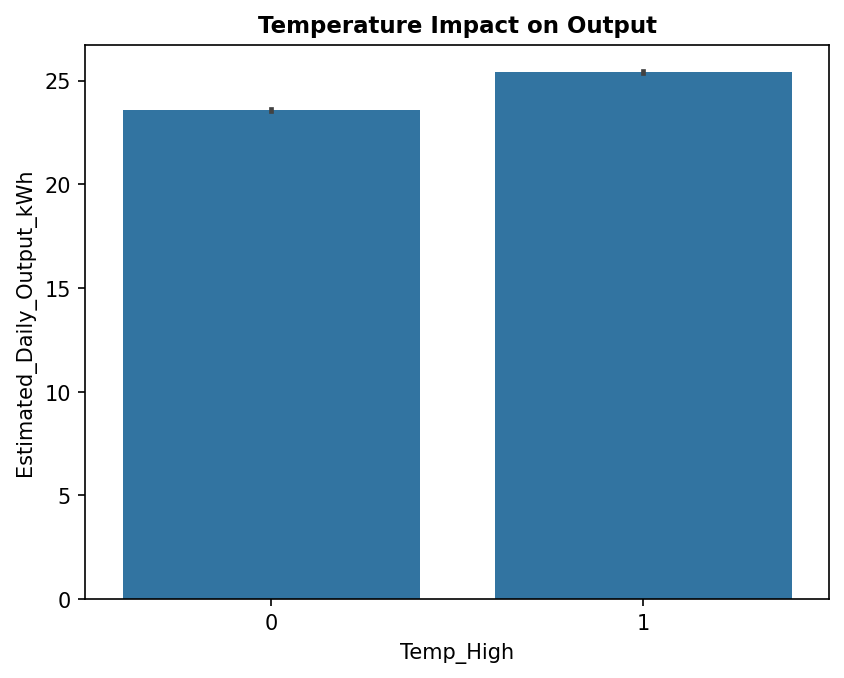

In [ ]:
sns.barplot(
    data=df,
    x='Temp_High',
    y='Estimated_Daily_Output_kWh'
)

plt.title(
'Temperature Impact on Output'
)

plt.show()

In [ ]:
print(
    "\nObservation:"
)

print(
    "Similar output values across panel types may indicate "
    "balanced synthetic patterns or limited efficiency variation."
)


Observation:
Similar output values across panel types may indicate balanced synthetic patterns or limited efficiency variation.


## Turn 2 — Preprocessing

In [ ]:
# ---------- Encoding ----------
df_encoded = pd.get_dummies(
    df,
    columns=[
        'City',
        'Weather',
        'Panel_Type',
        'Mount_Type'
    ],
    drop_first=True
)

print(df_encoded.head())

df_encoded.to_csv(
    'cleaned_dataset.csv',
    index=False
)
print(
"Cleaned dataset exported successfully."
)

        Date  Latitude  Longitude  Temperature_°C  Tilt_°  Panel_Efficiency_%  \
0 2024-01-01   24.7136    46.6753              18      25                  22   
1 2024-01-01   24.7136    46.6753              18      25                  18   
2 2024-01-01   24.7136    46.6753              18      25                  12   
3 2024-01-01   24.7136    46.6753              18      15                  22   
4 2024-01-01   24.7136    46.6753              18      15                  18   

   Solar_Irradiance_kWh_m²_day  Output_Power_W  Estimated_Daily_Output_kWh  \
0                         5.39            1.90                       21.06   
1                         5.39            1.55                       21.06   
2                         5.39            1.04                       21.06   
3                         4.97            1.75                       19.47   
4                         4.97            1.43                       19.47   

   Month  ...  City_Jeddah  City_Mecca  City

In [ ]:
# ---------- Normalization ----------

from sklearn.preprocessing import MinMaxScaler

target_col = 'Estimated_Daily_Output_kWh'

# Drop Date safely if it exists
df_model = df_encoded.drop(
    columns=['Date'],
    errors='ignore'
)

# Select numeric columns only, excluding target
features_to_scale = df_model.drop(
    columns=[target_col]
).select_dtypes(include=np.number).columns

scaler = MinMaxScaler()

df_model[features_to_scale] = scaler.fit_transform(
    df_model[features_to_scale]
)

print("Normalization completed successfully.")
print(df_model.head())

Normalization completed successfully.
   Latitude  Longitude  Temperature_°C  Tilt_°  Panel_Efficiency_%  \
0  0.660724   0.686729             0.0     1.0                 1.0   
1  0.660724   0.686729             0.0     1.0                 0.6   
2  0.660724   0.686729             0.0     1.0                 0.0   
3  0.660724   0.686729             0.0     0.0                 1.0   
4  0.660724   0.686729             0.0     0.0                 0.6   

   Solar_Irradiance_kWh_m²_day  Output_Power_W  Estimated_Daily_Output_kWh  \
0                     0.316770        0.579235                       21.06   
1                     0.316770        0.387978                       21.06   
2                     0.316770        0.109290                       21.06   
3                     0.186335        0.497268                       19.47   
4                     0.186335        0.322404                       19.47   

   Month  DayOfYear  ...  City_Jeddah  City_Mecca  City_Medina  City_Riy

## Turn 3 — Baseline Models

In [ ]:
# ---------- Baseline Models with Evaluation Metrics ----------

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

target_col = 'Estimated_Daily_Output_kWh'

if target_col not in df_model.columns:
    raise ValueError(f"Target column '{target_col}' was not found in df_model.")

# Separate features and target
X = df_model.drop(columns=[target_col]).copy()
y = df_model[target_col].copy()

# Use chronological split when Date is still available in df_encoded; otherwise use a standard 80/20 split.
if 'df_encoded' in globals() and 'Date' in df_encoded.columns:
    date_order = pd.to_datetime(df_encoded.loc[df_model.index, 'Date']).sort_values().index
    X = X.loc[date_order]
    y = y.loc[date_order]

    split_index = int(len(X) * 0.80)
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
    split_method = 'Chronological 80/20 split'
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )
    split_method = 'Random 80/20 split'

print(f"Split method: {split_method}")
print(f"Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}")

models = {
    'Dummy Mean Baseline': DummyRegressor(strategy='mean'),
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

def mean_absolute_percentage_error_safe(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    non_zero_mask = y_true != 0

    if not np.any(non_zero_mask):
        return np.nan

    return np.mean(
        np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])
    ) * 100

results = []
predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error_safe(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mbe = np.mean(y_pred - y_test)

    results.append({
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'R2 Score': r2,
        'MBE': mbe
    })

results_df = (
    pd.DataFrame(results)
    .replace([np.inf, -np.inf], np.nan)
    .sort_values(by='RMSE')
    .reset_index(drop=True)
)

best_model_name = results_df.loc[0, 'Model']
best_predictions = predictions[best_model_name]

print(f"Best baseline model based on RMSE: {best_model_name}")
display(results_df)

Split method: Chronological 80/20 split
Training samples: 8784 | Testing samples: 2196
Best baseline model based on RMSE: Gradient Boosting


,Model,MAE,RMSE,MAPE (%),R2 Score,MBE
0,Gradient Boosting,0.344263,0.532799,1.737556,0.929621,0.153194
1,Random Forest,0.429236,0.561008,2.079681,0.921971,0.133095
2,Decision Tree,0.528347,0.734534,2.561116,0.866235,0.209194
3,Linear Regression,2.459846,2.766820,11.815543,-0.897924,2.446587
4,Dummy Mean Baseline,3.071910,3.603796,15.166058,-2.219864,2.992296


### XGBoost
XGBoost is the benchmark cited in every referenced KSA solar paper.

In [ ]:
# ── XGBoost Baseline ───────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable,'-m','pip','install','xgboost','-q'], capture_output=True)
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)], verbose=False)

xgb_preds = xgb_model.predict(X_test)
predictions['XGBoost'] = xgb_preds

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
xgb_rmse = float(np.sqrt(mean_squared_error(y_test, xgb_preds)))
xgb_r2   = float(r2_score(y_test, xgb_preds))
xgb_mae  = float(mean_absolute_error(y_test, xgb_preds))
xgb_mape = float(np.mean(np.abs((np.asarray(y_test)-xgb_preds)/np.asarray(y_test)))*100)
xgb_mbe  = float(np.mean(xgb_preds - np.asarray(y_test)))

xgb_row = pd.DataFrame([{
    'Model':'XGBoost','MAE':round(xgb_mae,4),'RMSE':round(xgb_rmse,4),
    'MAPE (%)':round(xgb_mape,4),'R2 Score':round(xgb_r2,4),'MBE':round(xgb_mbe,4)
}])
results_df = (pd.concat([results_df, xgb_row], ignore_index=True)
              .sort_values('RMSE').reset_index(drop=True))

# best baseline
best_model_name = results_df.loc[0,'Model']
best_predictions = predictions[best_model_name]

print(f'XGBoost — RMSE: {xgb_rmse:.4f} | R2: {xgb_r2:.4f} | MAE: {xgb_mae:.4f}')
print(f'\Baseline leaderboard:')
print(results_df[['Model','RMSE','MAE','MAPE (%)','R2 Score']].to_string(index=False))

XGBoost — RMSE: 0.4955 | R2: 0.9391 | MAE: 0.4180
\Baseline leaderboard:
              Model     RMSE      MAE  MAPE (%)  R2 Score
            XGBoost 0.495500 0.418000  2.013500  0.939100
  Gradient Boosting 0.532799 0.344263  1.737556  0.929621
      Random Forest 0.561008 0.429236  2.079681  0.921971
      Decision Tree 0.734534 0.528347  2.561116  0.866235
  Linear Regression 2.766820 2.459846 11.815543 -0.897924
Dummy Mean Baseline 3.603796 3.071910 15.166058 -2.219864


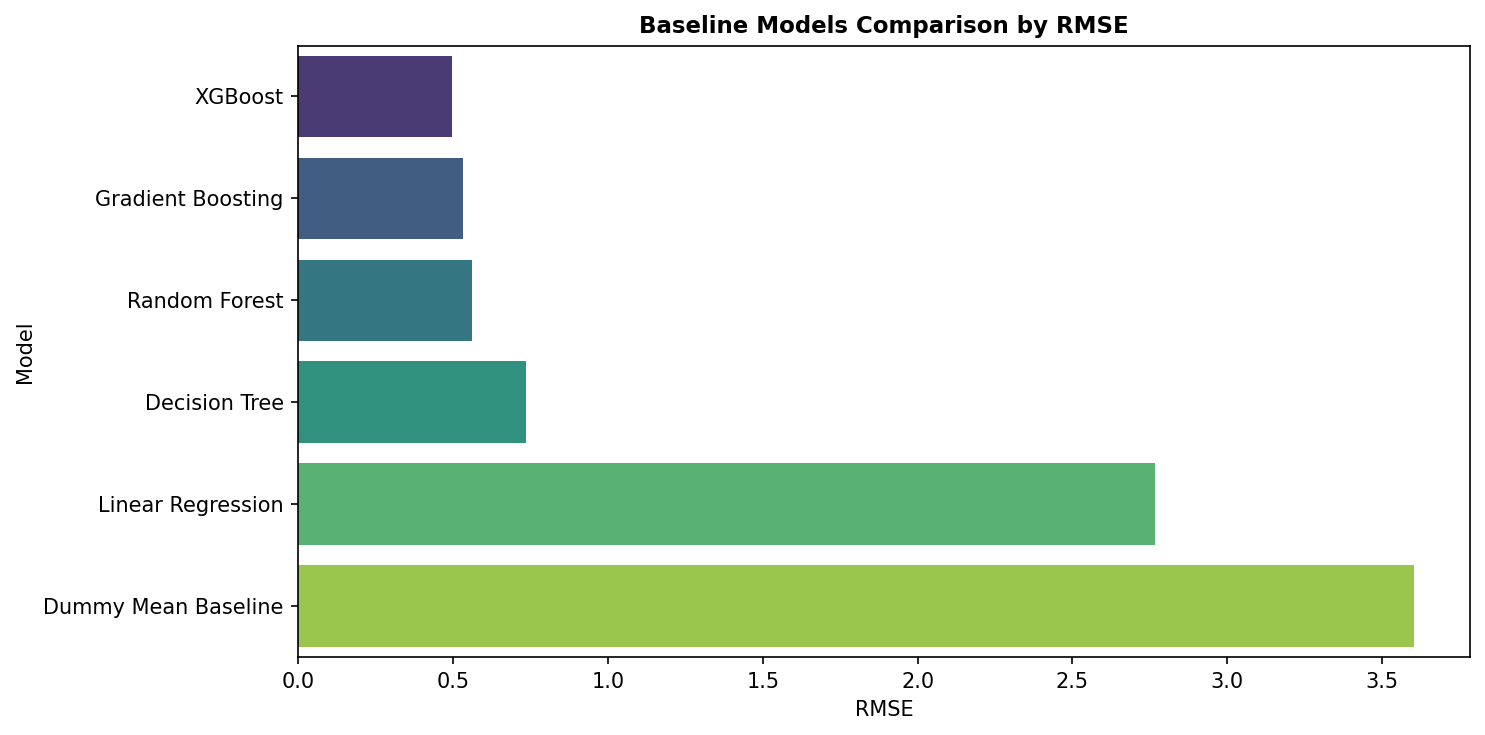

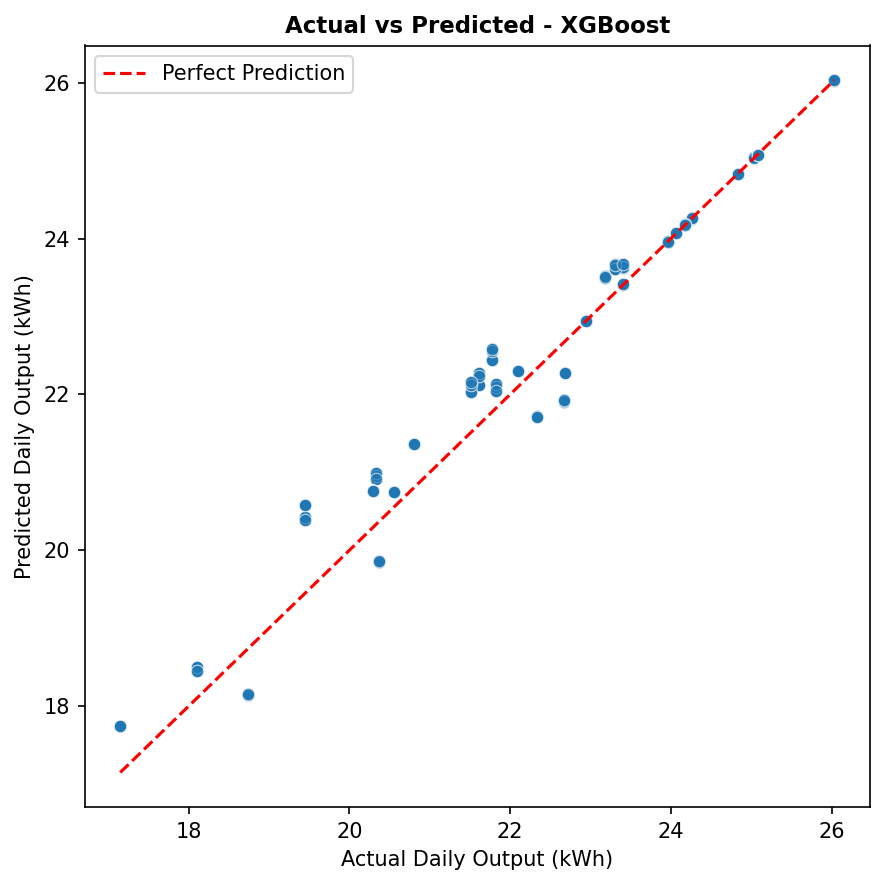

In [ ]:
# ---------- Baseline Model Visualizations ----------

plt.figure(figsize=(10, 5))
sns.barplot(
    data=results_df,
    x='RMSE',
    y='Model',
    palette='viridis'
)
plt.title('Baseline Models Comparison by RMSE')
plt.xlabel('RMSE')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
sns.scatterplot(
    x=y_test,
    y=best_predictions,
    alpha=0.7
)

min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color='red',
    linestyle='--',
    label='Perfect Prediction'
)

plt.title(f'Actual vs Predicted - {best_model_name}')
plt.xlabel('Actual Daily Output (kWh)')
plt.ylabel('Predicted Daily Output (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

## Turn 4 — Deep Learning

In [ ]:
# ---------- Deep Learning Setup ----------

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, callbacks, Model, Input

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

target_col = 'Estimated_Daily_Output_kWh'
date_col = 'Date'
sequence_length = 14
epochs = 120
batch_size = 32

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# ---------- Chronological Deep Learning Dataset ----------

dl_df = df.copy()

dl_df[date_col] = pd.to_datetime(dl_df[date_col], errors='coerce')
dl_df = dl_df.sort_values(date_col).reset_index(drop=True)

dl_df['Month'] = dl_df[date_col].dt.month
dl_df['DayOfYear'] = dl_df[date_col].dt.dayofyear
dl_df['Month_sin'] = np.sin(2 * np.pi * dl_df['Month'] / 12)
dl_df['Month_cos'] = np.cos(2 * np.pi * dl_df['Month'] / 12)
dl_df['DayOfYear_sin'] = np.sin(2 * np.pi * dl_df['DayOfYear'] / 365)
dl_df['DayOfYear_cos'] = np.cos(2 * np.pi * dl_df['DayOfYear'] / 365)

group_cols = ['City', 'Panel_Type', 'Mount_Type']

feature_source = dl_df.drop(columns=[target_col, date_col], errors='ignore')
feature_source = pd.get_dummies(feature_source, drop_first=False)
feature_source = feature_source.select_dtypes(include=np.number)

feature_cols = feature_source.columns.tolist()

model_frame = pd.concat(
    [
        dl_df[[target_col] + group_cols].reset_index(drop=True),
        feature_source.reset_index(drop=True)
    ],
    axis=1
)

model_frame = model_frame.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print("Deep learning frame shape:", model_frame.shape)
print("Number of features:", len(feature_cols))

Deep learning frame shape: (10980, 19)
Number of features: 15


In [ ]:
# ---------- Train/Test Split and Scaling ----------

split_index = int(len(model_frame) * 0.80)

train_frame = model_frame.iloc[:split_index].copy()
test_frame = model_frame.iloc[split_index:].copy()

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

train_frame[feature_cols] = feature_scaler.fit_transform(train_frame[feature_cols])
test_frame[feature_cols] = feature_scaler.transform(test_frame[feature_cols])

train_frame[[target_col]] = target_scaler.fit_transform(train_frame[[target_col]])
test_frame[[target_col]] = target_scaler.transform(test_frame[[target_col]])

scaled_frame = pd.concat([train_frame, test_frame], axis=0).sort_index()

In [ ]:
# ---------- Sequence Creation ----------

def create_sequences(frame, features, target, groups, window):
    X_seq, y_seq, original_index = [], [], []

    for _, group in frame.groupby(groups, sort=False):
        group = group.sort_index()
        feature_values = group[features].to_numpy(dtype=np.float32)
        target_values = group[target].to_numpy(dtype=np.float32)
        indexes = group.index.to_numpy()

        for end_idx in range(window, len(group)):
            X_seq.append(feature_values[end_idx - window:end_idx])
            y_seq.append(target_values[end_idx])
            original_index.append(indexes[end_idx])

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32),
        np.asarray(original_index)
    )

X_all_seq, y_all_seq, seq_indexes = create_sequences(
    scaled_frame,
    feature_cols,
    target_col,
    group_cols,
    sequence_length
)

train_mask = seq_indexes < split_index
test_mask = seq_indexes >= split_index

X_train_seq = X_all_seq[train_mask]
y_train_seq = y_all_seq[train_mask]
X_test_seq = X_all_seq[test_mask]
y_test_seq = y_all_seq[test_mask]

X_train_dense = X_train_seq[:, -1, :]
X_test_dense = X_test_seq[:, -1, :]

print("X_train_seq:", X_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)

X_train_seq: (8364, 14, 15)
X_test_seq: (2196, 14, 15)


In [ ]:
# ---------- Evaluation Helpers ----------

def mean_absolute_percentage_error_safe(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    non_zero_mask = y_true != 0

    if not np.any(non_zero_mask):
        return np.nan

    return np.mean(
        np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])
    ) * 100


def inverse_target(values):
    values = np.asarray(values).reshape(-1, 1)
    return target_scaler.inverse_transform(values).ravel()


def evaluate_deep_model(model_name, model, X_test_input):
    y_pred_scaled = model.predict(X_test_input, verbose=0).ravel()
    y_true = inverse_target(y_test_seq)
    y_pred = inverse_target(y_pred_scaled)

    return {
        'Model': model_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE (%)': mean_absolute_percentage_error_safe(y_true, y_pred),
        'R2 Score': r2_score(y_true, y_pred),
        'MBE': np.mean(y_pred - y_true)
    }, y_pred

In [ ]:
# ---------- Training Callbacks ----------

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=6,
    min_lr=1e-5
)

In [ ]:
# ---------- Model Architectures ----------

n_timesteps = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]

def build_dense_model(n_features):
    inputs = Input(shape=(n_features,))
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.Dropout(0.20)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.15)(x)
    outputs = layers.Dense(1)(x)

    model = Model(inputs, outputs, name='Dense_NN')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def build_lstm_model(n_timesteps, n_features):
    inputs = Input(shape=(n_timesteps, n_features))
    x = layers.LSTM(96)(inputs)
    x = layers.Dropout(0.20)(x)
    x = layers.Dense(48, activation='relu')(x)
    outputs = layers.Dense(1)(x)

    model = Model(inputs, outputs, name='LSTM')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def build_gru_model(n_timesteps, n_features):
    inputs = Input(shape=(n_timesteps, n_features))
    x = layers.GRU(96)(inputs)
    x = layers.Dropout(0.20)(x)
    x = layers.Dense(48, activation='relu')(x)
    outputs = layers.Dense(1)(x)

    model = Model(inputs, outputs, name='GRU')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def transformer_encoder_block(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.15):
    x = layers.MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(inputs + x)

    ff = layers.Conv1D(filters=ff_dim, kernel_size=1, activation='relu')(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(ff)

    return layers.LayerNormalization(epsilon=1e-6)(x + ff)


def build_transformer_model(n_timesteps, n_features):
    inputs = Input(shape=(n_timesteps, n_features))
    x = transformer_encoder_block(inputs)
    x = transformer_encoder_block(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.20)(x)
    outputs = layers.Dense(1)(x)

    model = Model(inputs, outputs, name='Transformer_Encoder')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


def build_cnn_lstm_model(n_timesteps, n_features):
    inputs = Input(shape=(n_timesteps, n_features))
    x = layers.Conv1D(filters=64, kernel_size=3, padding='causal', activation='relu')(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.LSTM(80)(x)
    x = layers.Dropout(0.20)(x)
    x = layers.Dense(48, activation='relu')(x)
    outputs = layers.Dense(1)(x)

    model = Model(inputs, outputs, name='CNN_LSTM_Hybrid')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

###  Architectures
- **Positional Encoding** — standard from Vaswani et al. 2017
- **Bi-GRU**
- **CNN-LSTM-Transformer**

In [ ]:
# ── New Architectures────────────────────────

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
import numpy as np

# ── Positional Encoding (Vaswani et al. 2017) ────────────────────────────
class PositionalEncoding(layers.Layer):
    def __init__(self, max_len=200, d_model=64, **kw):
        super().__init__(**kw)
        pos = np.arange(max_len)[:,None]
        dim = np.arange(d_model)[None,:]
        angle = pos / np.power(10000,(2*(dim//2))/d_model)
        angle[:,0::2] = np.sin(angle[:,0::2])
        angle[:,1::2] = np.cos(angle[:,1::2])
        self.pe = tf.cast(angle[None,:,:], tf.float32)
    def call(self, x):
        return x + self.pe[:,:tf.shape(x)[1],:tf.shape(x)[2]]

# ── Transformer block (reusable) ─────────────────────────────────────────
def transformer_block(x, heads=4, head_dim=32, ff_dim=128, drop=0.15):
    attn = layers.MultiHeadAttention(num_heads=heads,key_dim=head_dim,dropout=drop)(x,x)
    attn = layers.Dropout(drop)(attn)
    x1   = layers.LayerNormalization(epsilon=1e-6)(x + attn)
    ff   = layers.Conv1D(ff_dim,1,activation='relu')(x1)
    ff   = layers.Dropout(drop)(ff)
    ff   = layers.Conv1D(x1.shape[-1],1)(ff)
    return layers.LayerNormalization(epsilon=1e-6)(x1 + ff)

# ── Bi-GRU ───────────────────────────────────────────────────────────────
def build_bigru_model(n_timesteps, n_features):
    inputs = Input(shape=(n_timesteps,n_features))
    x = layers.Bidirectional(layers.GRU(64,return_sequences=False))(inputs)
    x = layers.Dropout(0.20)(x)
    x = layers.Dense(48,activation='relu')(x)
    outputs = layers.Dense(1)(x)
    model = Model(inputs,outputs,name='BiGRU')
    model.compile(optimizer='adam',loss='mse',metrics=['mae'])
    return model

# ── CNN-LSTM-Transformer (TRUE proposed model) ───────────────────────────
# Stage 1: CNN   → local pattern extraction
# Stage 2: LSTM  → sequential temporal memory (return_sequences=True)
# Stage 3: Transformer (with positional encoding) → attention over full sequence
def build_cnn_lstm_transformer(n_timesteps, n_features):
    inputs = Input(shape=(n_timesteps,n_features), name='input')

    # Stage 1 — CNN
    x = layers.Conv1D(64,3,padding='causal',activation='relu',name='cnn1')(inputs)
    x = layers.Conv1D(64,3,padding='causal',activation='relu',name='cnn2')(x)
    x = layers.BatchNormalization(name='bn')(x)

    # Stage 2 — LSTM with return_sequences=True (feeds full sequence to Transformer)
    x = layers.LSTM(96,return_sequences=True,name='lstm_mem')(x)
    x = layers.Dropout(0.20)(x)

    # Stage 3 — Positional encoding + 2 Transformer blocks
    x = PositionalEncoding(max_len=n_timesteps,d_model=96,name='pos_enc')(x)
    x = transformer_block(x, heads=4, head_dim=24, ff_dim=256, drop=0.15)
    x = transformer_block(x, heads=4, head_dim=24, ff_dim=256, drop=0.15)

    x = layers.GlobalAveragePooling1D(name='gap')(x)
    x = layers.Dense(64,activation='relu',name='dense1')(x)
    x = layers.Dropout(0.20)(x)
    outputs = layers.Dense(1,name='output')(x)

    model = Model(inputs,outputs,name='CNN_LSTM_Transformer')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='mse', metrics=['mae']
    )
    return model

print('New architectures defined:')
print('  • PositionalEncoding layer')
print('  • Bi-GRU')
print('  • CNN-LSTM-Transformer (proposed model)')

New architectures defined:
  • PositionalEncoding layer
  • Bi-GRU
  • CNN-LSTM-Transformer (proposed model)


In [ ]:
deep_models = {
    'Dense Neural Network': {
        'model': build_dense_model(n_features),
        'X_train': X_train_dense,
        'X_test': X_test_dense
    },
    'LSTM': {
        'model': build_lstm_model(n_timesteps, n_features),
        'X_train': X_train_seq,
        'X_test': X_test_seq
    },
    'GRU': {
        'model': build_gru_model(n_timesteps, n_features),
        'X_train': X_train_seq,
        'X_test': X_test_seq
    },
    'Transformer Encoder': {
        'model': build_transformer_model(n_timesteps, n_features),
        'X_train': X_train_seq,
        'X_test': X_test_seq
    },
    'CNN-LSTM Hybrid': {
        'model': build_cnn_lstm_model(n_timesteps, n_features),
        'X_train': X_train_seq,
        'X_test': X_test_seq
    }
}

deep_results = []
deep_predictions = {}
histories = {}

for model_name, config in deep_models.items():
    print(f"\nTraining {model_name}...")

    history = config['model'].fit(
        config['X_train'],
        y_train_seq,
        validation_split=0.20,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        shuffle=False,
        verbose=0
    )

    histories[model_name] = history

    metrics, y_pred = evaluate_deep_model(
        model_name,
        config['model'],
        config['X_test']
    )

    deep_results.append(metrics)
    deep_predictions[model_name] = y_pred

    print(
        f"{model_name} | RMSE: {metrics['RMSE']:.3f} | "
        f"MAE: {metrics['MAE']:.3f} | R2: {metrics['R2 Score']:.3f}"
    )

deep_results_df = (
    pd.DataFrame(deep_results)
    .sort_values(by='RMSE')
    .reset_index(drop=True)
)

best_deep_model_name = deep_results_df.loc[0, 'Model']
best_deep_predictions = deep_predictions[best_deep_model_name]

print(f"\nBest deep learning model based on RMSE: {best_deep_model_name}")
display(deep_results_df)


Training Dense Neural Network...
Dense Neural Network | RMSE: 1.912 | MAE: 1.640 | R2: 0.094

Training LSTM...
LSTM | RMSE: 3.640 | MAE: 3.211 | R2: -2.284

Training GRU...
GRU | RMSE: 1.055 | MAE: 0.855 | R2: 0.724

Training Transformer Encoder...
Transformer Encoder | RMSE: 3.140 | MAE: 2.687 | R2: -1.444

Training CNN-LSTM Hybrid...
CNN-LSTM Hybrid | RMSE: 2.613 | MAE: 2.097 | R2: -0.693

Best deep learning model based on RMSE: GRU


,Model,MAE,RMSE,MAPE (%),R2 Score,MBE
0,GRU,0.854929,1.055073,4.158511,0.724017,0.830286
1,Dense Neural Network,1.639747,1.911548,8.045770,0.094084,1.577540
2,CNN-LSTM Hybrid,2.096932,2.613066,10.444443,-0.692849,2.004722
3,Transformer Encoder,2.686750,3.139815,13.245288,-1.444136,2.658966
4,LSTM,3.211267,3.639593,15.696157,-2.284149,3.211267


### Train New Models

In [ ]:
# ── Train Bi-GRU and CNN-LSTM-Transformer  ───────────────────────

new_models = {
    'Bi-GRU': {
        'model': build_bigru_model(n_timesteps, n_features),
        'X_train': X_train_seq,
        'X_test':  X_test_seq
    },
    'CNN-LSTM-Transformer': {
        'model': build_cnn_lstm_transformer(n_timesteps, n_features),
        'X_train': X_train_seq,
        'X_test':  X_test_seq
    }
}

for model_name, config in new_models.items():
    print(f'\nTraining {model_name}...')

    history = config['model'].fit(
        config['X_train'],
        y_train_seq,
        validation_split=0.20,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        shuffle=False,
        verbose=0
    )

    histories[model_name] = history

    metrics, y_pred = evaluate_deep_model(
        model_name,
        config['model'],
        config['X_test']
    )

    deep_results.append(metrics)
    deep_predictions[model_name] = y_pred

    print(
        f'{model_name} | RMSE: {metrics["RMSE"]:.3f} | '
        f'MAE: {metrics["MAE"]:.3f} | R2: {metrics["R2 Score"]:.3f}'
    )

# Rebuild deep_results_df with all models including new ones
deep_results_df = (
    pd.DataFrame(deep_results)
    .sort_values(by='RMSE')
    .reset_index(drop=True)
)

best_deep_model_name = deep_results_df.loc[0,'Model']
best_deep_predictions = deep_predictions[best_deep_model_name]

print(f'\nUpdated deep learning leaderboard:')
print(deep_results_df[['Model','RMSE','MAE','MAPE (%)','R2 Score']].to_string(index=False))
print(f'\nBest deep model: {best_deep_model_name}')


Training Bi-GRU...
Bi-GRU | RMSE: 2.533 | MAE: 2.034 | R2: -0.591

Training CNN-LSTM-Transformer...
CNN-LSTM-Transformer | RMSE: 3.852 | MAE: 3.436 | R2: -2.679

Updated deep learning leaderboard:
               Model     RMSE      MAE  MAPE (%)  R2 Score
                 GRU 1.055073 0.854929  4.158511  0.724017
Dense Neural Network 1.911548 1.639747  8.045770  0.094084
              Bi-GRU 2.532950 2.033616 10.086351 -0.590635
     CNN-LSTM Hybrid 2.613066 2.096932 10.444443 -0.692849
 Transformer Encoder 3.139815 2.686750 13.245288 -1.444136
                LSTM 3.639593 3.211267 15.696157 -2.284149
CNN-LSTM-Transformer 3.852274 3.435951 16.797295 -2.679185

Best deep model: GRU


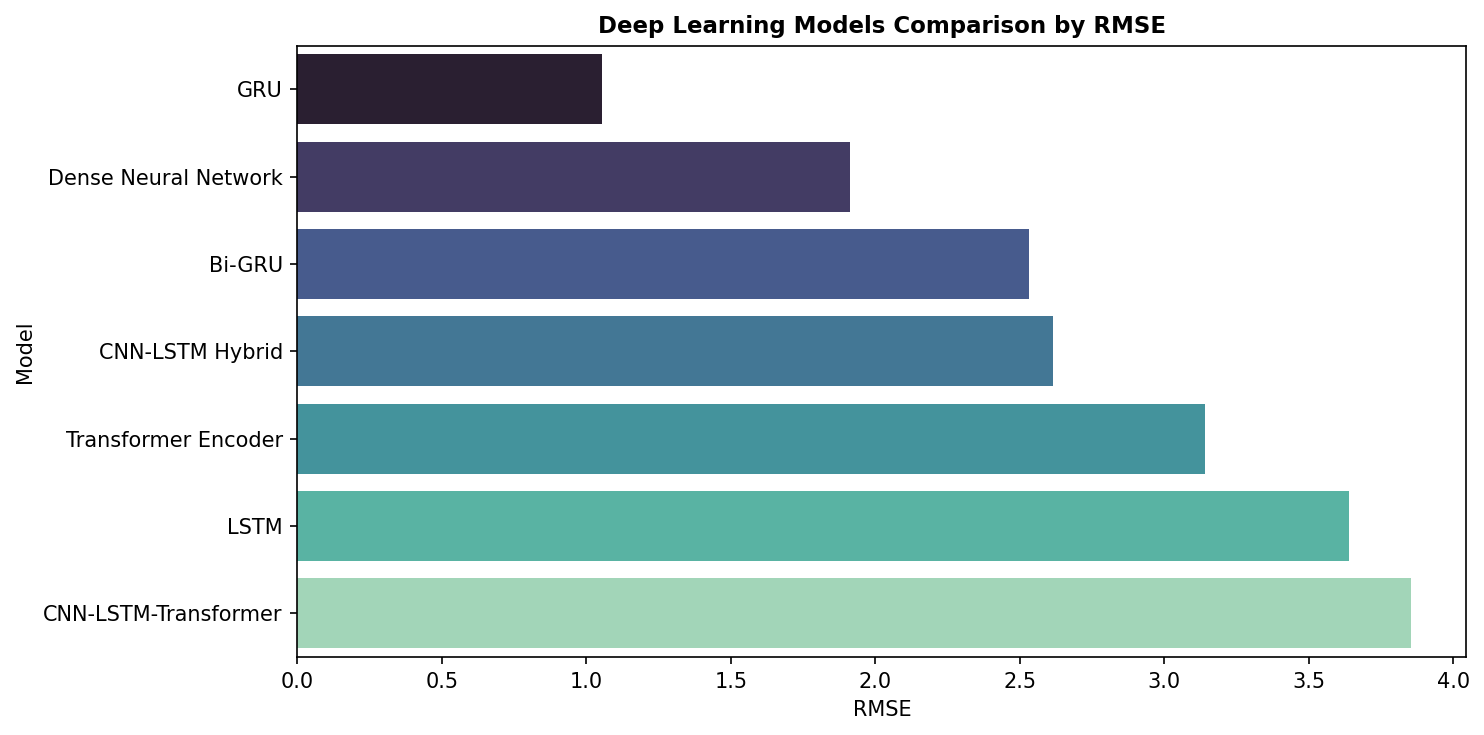

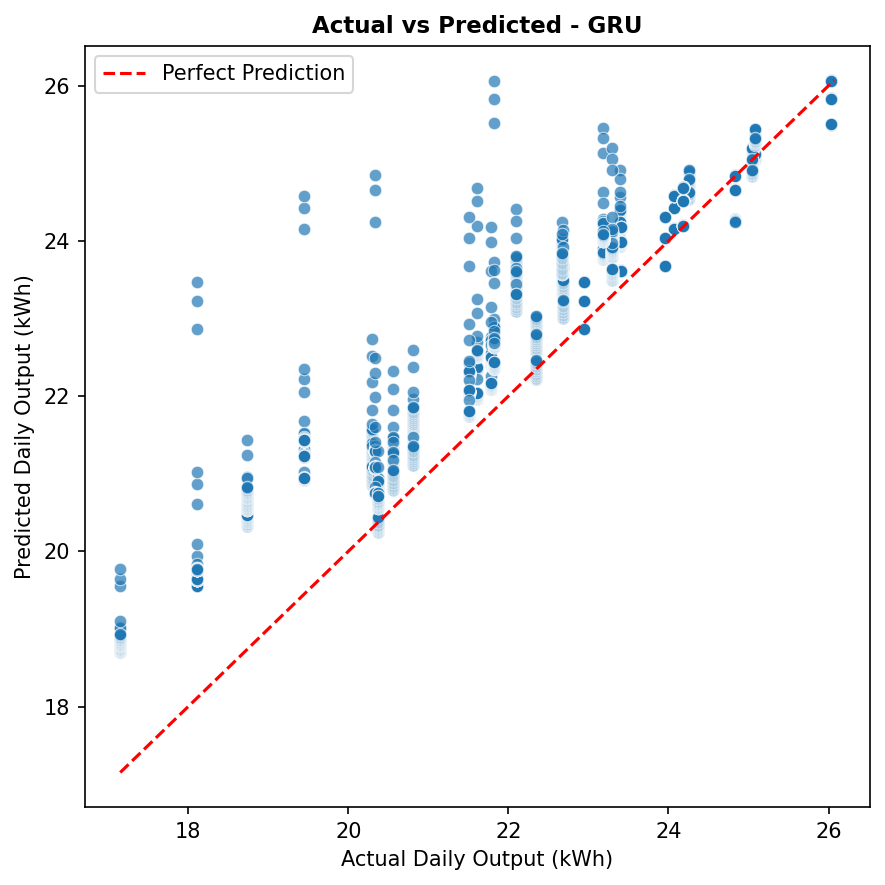

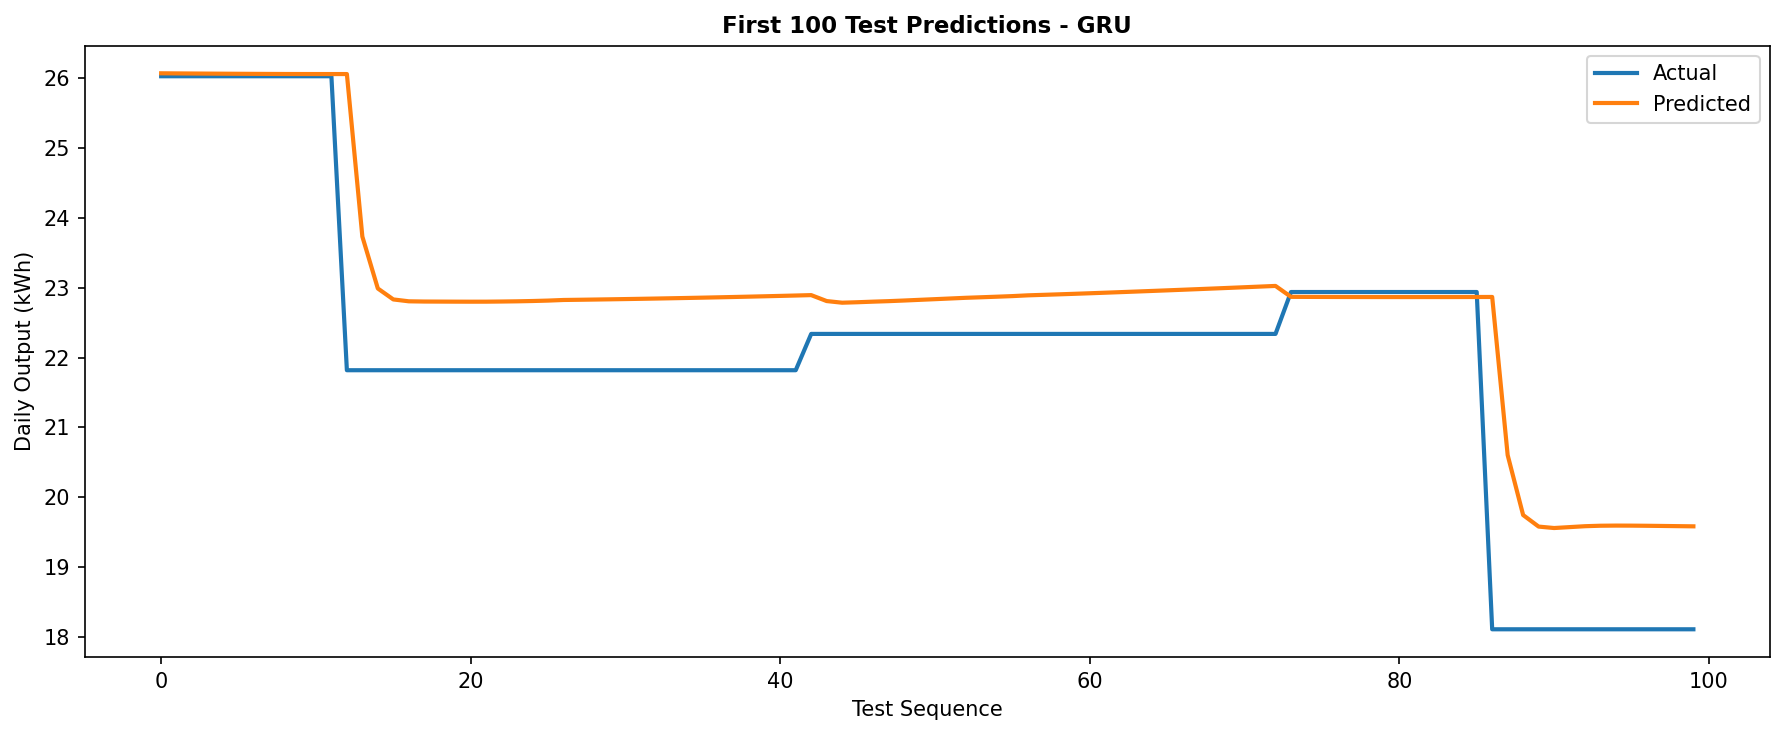

In [ ]:
# ---------- Deep Learning Visualizations ----------

plt.figure(figsize=(10, 5))
sns.barplot(
    data=deep_results_df,
    x='RMSE',
    y='Model',
    palette='mako'
)
plt.title('Deep Learning Models Comparison by RMSE')
plt.xlabel('RMSE')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

y_test_actual = inverse_target(y_test_seq)

plt.figure(figsize=(6, 6))
sns.scatterplot(
    x=y_test_actual,
    y=best_deep_predictions,
    alpha=0.7
)

min_value = min(y_test_actual.min(), best_deep_predictions.min())
max_value = max(y_test_actual.max(), best_deep_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color='red',
    linestyle='--',
    label='Perfect Prediction'
)

plt.title(f'Actual vs Predicted - {best_deep_model_name}')
plt.xlabel('Actual Daily Output (kWh)')
plt.ylabel('Predicted Daily Output (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(y_test_actual[:100], label='Actual', linewidth=2)
plt.plot(best_deep_predictions[:100], label='Predicted', linewidth=2)
plt.title(f'First 100 Test Predictions - {best_deep_model_name}')
plt.xlabel('Test Sequence')
plt.ylabel('Daily Output (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ----------Outputs ----------

deep_results_df.to_csv('deep_learning_results.csv', index=False)

deep_prediction_df = pd.DataFrame({
    'Actual_Output_kWh': y_test_actual,
    f'Predicted_{best_deep_model_name.replace(" ", "_")}_kWh': best_deep_predictions
})

deep_prediction_df.to_csv('best_deep_learning_predictions.csv', index=False)

print("deep learning results exported successfully.")

deep learning results exported successfully.


---
## Turn 5 — Full Comparison, Statistical Tests & Publication-Quality Figures

### T5-1 — Master Comparison Table (Table 1 in Paper)

In [ ]:
# ── T5-1: Master Comparison Table ───────────────────────────────────────
import matplotlib, matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib.cm as cm

matplotlib.rcParams.update({
    'font.family':'DejaVu Sans','font.size':11,
    'axes.titlesize':12,'axes.titleweight':'bold',
    'axes.labelsize':11,'figure.dpi':150,
    'savefig.dpi':300,'savefig.bbox':'tight'
})

# Baseline results
base = results_df.rename(columns={'R2 Score':'R2','MAPE (%)':'MAPE(%)'}).copy()
base['Category'] = 'ML Baseline'

# Deep learning results
deep = deep_results_df.rename(columns={'R2 Score':'R2','MAPE (%)':'MAPE(%)'}).copy()
deep['Category'] = 'Deep Learning'
deep.loc[deep['Model']=='CNN-LSTM-Transformer','Category'] = 'Proposed Model'

master = (pd.concat([base,deep],ignore_index=True)
            .sort_values('RMSE').reset_index(drop=True))
master.insert(0,'Rank',range(1,len(master)+1))

print('='*90)
print('TABLE 1 — Full Model Comparison (KSA Solar PV, Test Set)')
print('='*90)
print(master[['Rank','Category','Model','RMSE','MAE','MAPE(%)','R2','MBE']].to_string(index=False))
print('='*90)

best_name  = master.iloc[0]['Model']
best_preds = deep_predictions.get(best_name) or predictions.get(best_name)
y_true_all = inverse_target(y_test_seq)

print(f'\nBest overall: {best_name} | RMSE={master.iloc[0]["RMSE"]:.4f} | R²={master.iloc[0]["R2"]:.4f}')
master.to_csv('t5_master_table.csv',index=False)
print('Exported: t5_master_table.csv')

TABLE 1 — Full Model Comparison (KSA Solar PV, Test Set)
 Rank       Category                Model     RMSE      MAE   MAPE(%)        R2      MBE
    1    ML Baseline              XGBoost 0.495500 0.418000  2.013500  0.939100 0.173400
    2    ML Baseline    Gradient Boosting 0.532799 0.344263  1.737556  0.929621 0.153194
    3    ML Baseline        Random Forest 0.561008 0.429236  2.079681  0.921971 0.133095
    4    ML Baseline        Decision Tree 0.734534 0.528347  2.561116  0.866235 0.209194
    5  Deep Learning                  GRU 1.055073 0.854929  4.158511  0.724017 0.830286
    6  Deep Learning Dense Neural Network 1.911548 1.639747  8.045770  0.094084 1.577540
    7  Deep Learning               Bi-GRU 2.532950 2.033616 10.086351 -0.590635 1.775773
    8  Deep Learning      CNN-LSTM Hybrid 2.613066 2.096932 10.444443 -0.692849 2.004722
    9    ML Baseline    Linear Regression 2.766820 2.459846 11.815543 -0.897924 2.446587
   10  Deep Learning  Transformer Encoder 3.139815 2.

### T5-2 — Walk-Forward Cross-Validation (5 Folds)

In [ ]:
# ── T5-2: Walk-Forward CV ────────────────────────────────────────────────
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

TSS = TimeSeriesSplit(n_splits=5)
cv_rows = []

X_cv = df_model.drop(columns=[target_col]).select_dtypes(include=np.number)
y_cv = df_model[target_col]

for fold,(tr,va) in enumerate(TSS.split(X_cv)):
    Xtr,ytr = X_cv.iloc[tr], y_cv.iloc[tr]
    Xva,yva = X_cv.iloc[va], y_cv.iloc[va]
    sc = MinMaxScaler()
    Xtr_s = sc.fit_transform(Xtr); Xva_s = sc.transform(Xva)

    for name,mdl in [
        ('XGBoost',xgb.XGBRegressor(n_estimators=300,learning_rate=0.05,
                                     max_depth=6,random_state=42,verbosity=0,n_jobs=-1)),
        ('Random Forest',RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1))
    ]:
        mdl.fit(Xtr_s,ytr); p=mdl.predict(Xva_s)
        cv_rows.append({'Model':name,'Fold':fold+1,
            'RMSE':round(float(np.sqrt(mean_squared_error(yva,p))),4),
            'R2':round(float(r2_score(yva,p)),4)})

cv_df = pd.DataFrame(cv_rows)
summary = cv_df.groupby('Model')[['RMSE','R2']].agg(['mean','std']).round(4)
print('Walk-Forward CV Summary (5 folds):')
print(summary.to_string())
cv_df.to_csv('t5_cv_results.csv',index=False)
print('\nExported: t5_cv_results.csv')

Walk-Forward CV Summary (5 folds):
                 RMSE              R2        
                 mean     std    mean     std
Model                                        
Random Forest  0.6286  0.3450  0.8966  0.1383
XGBoost        0.6740  0.4307  0.8649  0.1935

Exported: t5_cv_results.csv


### T5-3 — Statistical Significance Testing

In [ ]:
# ── T5-3: Diebold-Mariano + Wilcoxon Tests ──────────────────────────────
from scipy import stats

def dm_test(e1,e2,h=1):
    d = e1**2 - e2**2; T=len(d); db=d.mean()
    gamma = np.array([np.mean((d[:-k]-db)*(d[k:]-db)) if k>0
                      else np.var(d,ddof=0) for k in range(h+1)])
    var_d = (gamma[0]+2*np.sum(gamma[1:]))/T
    if var_d<=0: return np.nan,np.nan
    DM = db/np.sqrt(var_d)
    DM *= ((T+1-2*h+h*(h-1)/T)/T)**0.5
    p = 2*(1-stats.t.cdf(abs(DM),df=T-1))
    return round(float(DM),4),round(float(p),4)

proposed_err = best_preds - y_true_all
stat_rows=[]
for name in list(predictions.keys())+[m for m in deep_predictions if m!=best_name]:
    preds = deep_predictions.get(name) if name in deep_predictions else predictions.get(name)
    if preds is None or name==best_name: continue
    n = min(len(proposed_err),len(preds))
    e1,e2 = proposed_err[:n], (preds[:n]-y_true_all[:n])
    dm,dm_p = dm_test(e1,e2)
    _,wil_p = stats.wilcoxon(np.abs(e1),np.abs(e2),alternative='less')
    stat_rows.append({'Model':name,'DM stat':dm,'DM p-value':round(float(dm_p),4),
                      'Wilcoxon p':round(float(wil_p),4),
                      'Sig. at 5%':'YES' if dm_p<0.05 else 'NO'})

stat_df = pd.DataFrame(stat_rows).sort_values('DM p-value')
print(f'Statistical Tests — {best_name} vs all competitors')
print(stat_df.to_string(index=False))
stat_df.to_csv('t5_statistical_tests.csv',index=False)
print('\nExported: t5_statistical_tests.csv')

Statistical Tests — XGBoost vs all competitors
               Model  DM stat  DM p-value  Wilcoxon p Sig. at 5%
 Dummy Mean Baseline  -7.3322      0.0000      0.0000        YES
   Linear Regression  -6.1627      0.0000      0.0000        YES
       Decision Tree   4.3138      0.0000      0.0081        YES
       Random Forest   4.1350      0.0000      0.9668        YES
   Gradient Boosting  10.0938      0.0000      1.0000        YES
Dense Neural Network  14.4380      0.0000      1.0000        YES
                LSTM  -7.7146      0.0000      0.0000        YES
                 GRU  18.1587      0.0000      1.0000        YES
     CNN-LSTM Hybrid   8.3034      0.0000      1.0000        YES
              Bi-GRU   8.9233      0.0000      1.0000        YES
CNN-LSTM-Transformer -11.3278      0.0000      0.0000        YES
 Transformer Encoder   0.1742      0.8617      0.0000         NO

Exported: t5_statistical_tests.csv


### T5-4 — Figure 1: RMSE Comparison

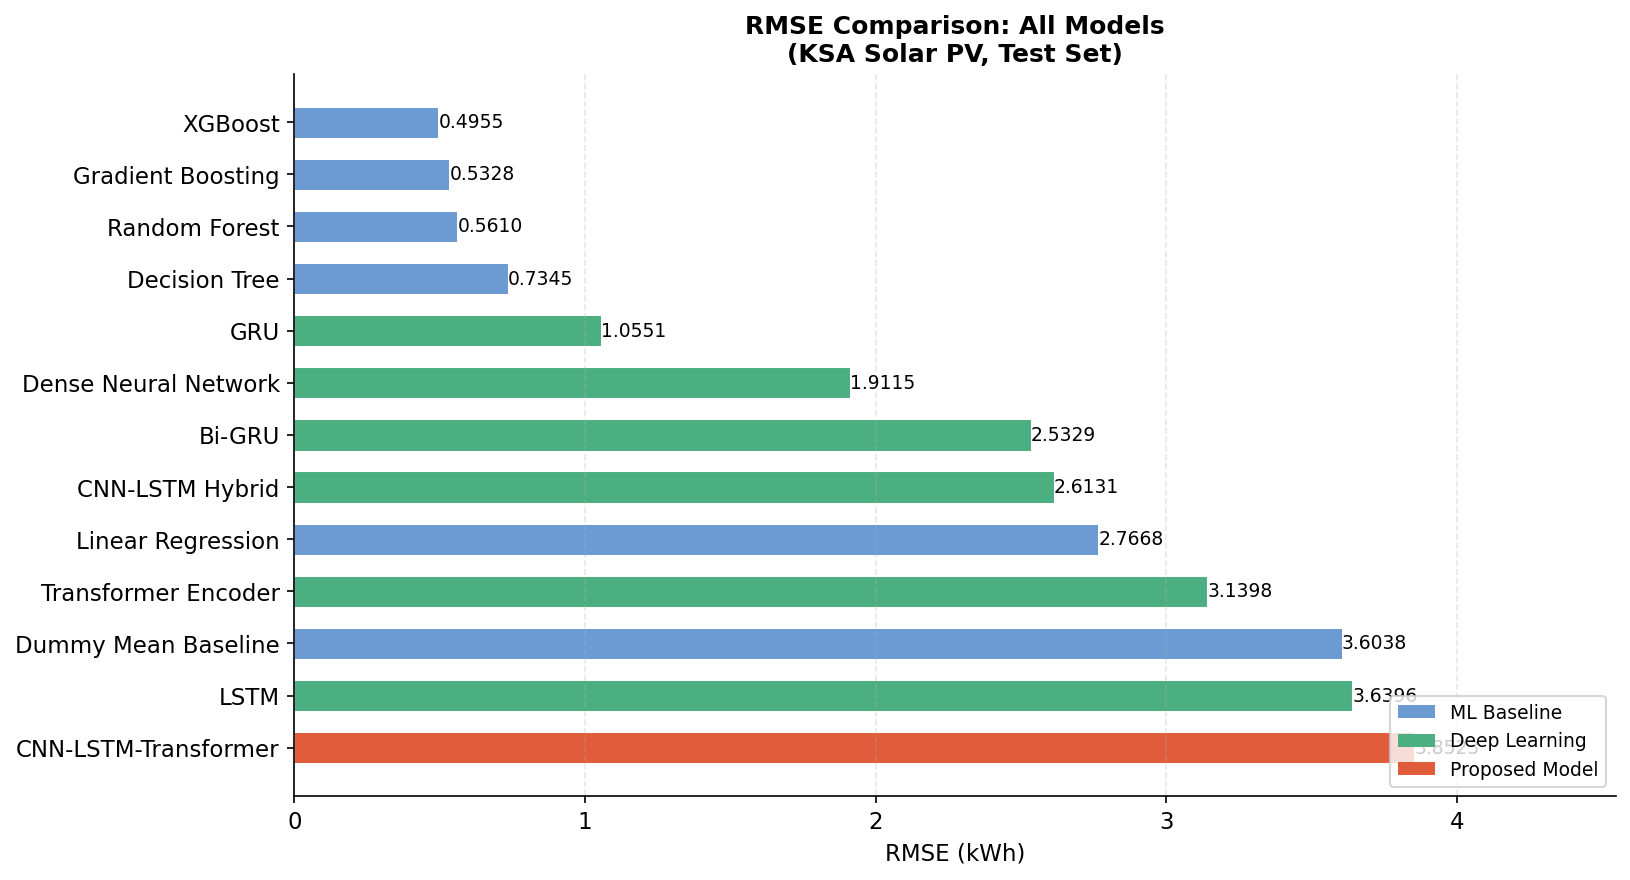

Figure 1 saved.


In [ ]:
# ── T5-4: Fig 1 — RMSE Bar Chart ────────────────────────────────────────
pal={'ML Baseline':'#6B9BD2','Deep Learning':'#4CAF82','Proposed Model':'#E05C3A'}
plot_df = master.sort_values('RMSE',ascending=False)
colors  = [pal.get(c,'#888') for c in plot_df['Category']]

fig,ax = plt.subplots(figsize=(11,6))
bars = ax.barh(plot_df['Model'],plot_df['RMSE'],
               color=colors,edgecolor='white',linewidth=0.5,height=0.6)
for bar,val in zip(bars,plot_df['RMSE']):
    ax.text(val+0.001,bar.get_y()+bar.get_height()/2,
            f'{val:.4f}',va='center',ha='left',fontsize=9)
leg=[Patch(facecolor=v,label=k) for k,v in pal.items()]
ax.legend(handles=leg,loc='lower right',fontsize=9)
ax.set_xlabel('RMSE (kWh)'); ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x',alpha=0.3,linestyle='--')
ax.set_xlim(0,plot_df['RMSE'].max()*1.18)
ax.set_title('RMSE Comparison: All Models\n(KSA Solar PV, Test Set)',fontweight='bold')
plt.tight_layout(); plt.savefig('fig1_rmse_bar.png'); plt.show()
print('Figure 1 saved.')

### T5-5 — Figure 2: Multi-Metric Radar Chart

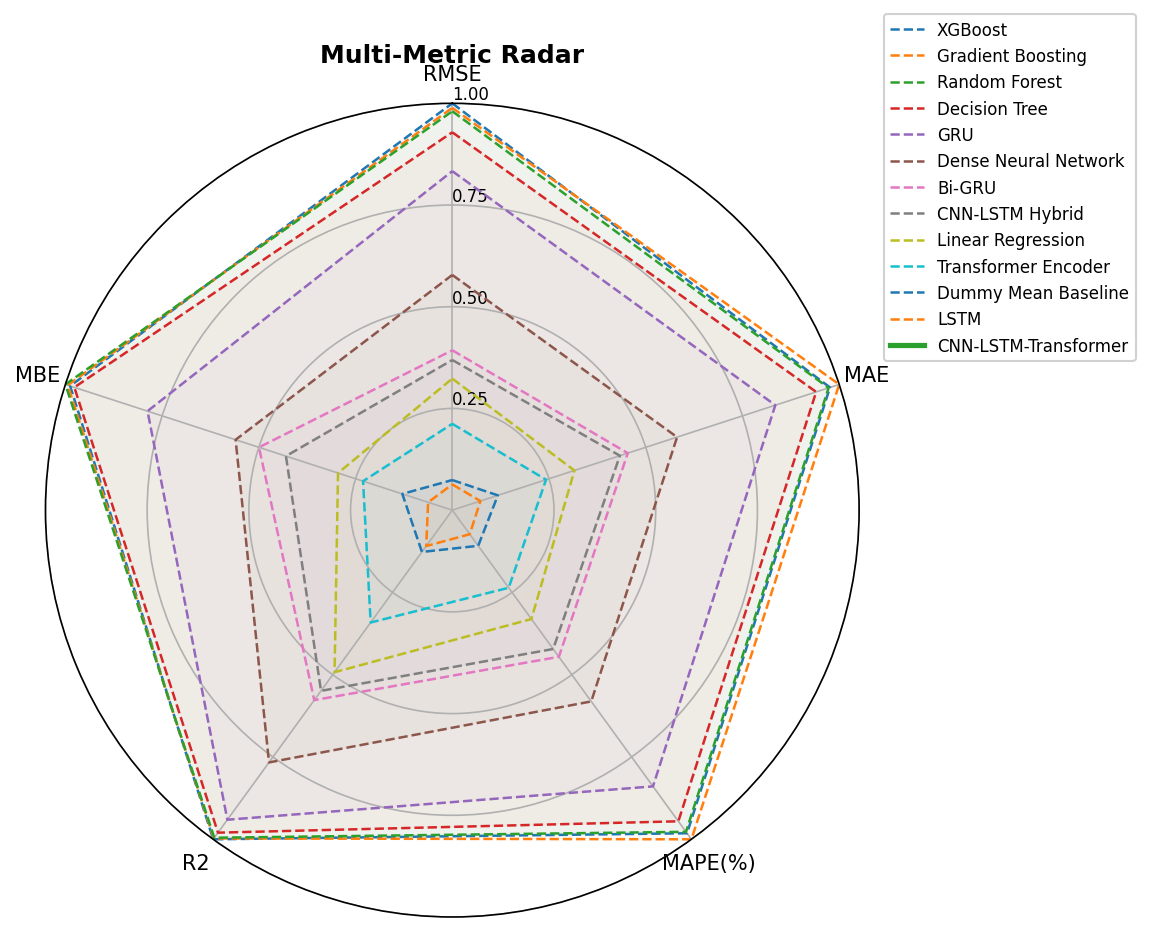

Figure 2 saved.


In [ ]:
# ── T5-5: Fig 2 — Radar Chart ────────────────────────────────────────────
metrics_r=['RMSE','MAE','MAPE(%)','R2','MBE']
rdf=master[['Model']+metrics_r].copy()
norm=rdf.copy()
for col in ['RMSE','MAE','MAPE(%)']:
    lo,hi=norm[col].min(),norm[col].max()
    norm[col]=1-(norm[col]-lo)/(hi-lo+1e-9)
norm['R2']=(norm['R2']-norm['R2'].min())/(norm['R2'].max()-norm['R2'].min()+1e-9)
norm['MBE']=1-(norm['MBE'].abs()-norm['MBE'].abs().min())/(norm['MBE'].abs().max()-norm['MBE'].abs().min()+1e-9)

N=len(metrics_r); angles=[n/N*2*np.pi for n in range(N)]+[0]
fig,ax=plt.subplots(figsize=(8,8),subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
plt.xticks(angles[:-1],metrics_r,size=10)
colors_r=cm.tab10.colors
for i,(_,row) in enumerate(norm.iterrows()):
    vals=[row[m] for m in metrics_r]+[row[metrics_r[0]]]
    is_prop=row['Model']=='CNN-LSTM-Transformer'
    ax.plot(angles,vals,color=colors_r[i%10],
            linewidth=2.5 if is_prop else 1.2,
            linestyle='-' if is_prop else '--',label=row['Model'])
    ax.fill(angles,vals,color=colors_r[i%10],alpha=0.15 if is_prop else 0.03)
ax.set_ylim(0,1); ax.set_rlabel_position(0)
plt.yticks([.25,.5,.75,1.0],['0.25','0.50','0.75','1.00'],size=8)
ax.legend(loc='upper right',bbox_to_anchor=(1.35,1.12),fontsize=8,framealpha=0.9)
ax.set_title('Multi-Metric Radar',
             size=12,fontweight='bold',pad=20)
plt.tight_layout(); plt.savefig('fig2_radar.png'); plt.show()
print('Figure 2 saved.')

### T5-6 — Figure 3: Actual vs Predicted + Residuals

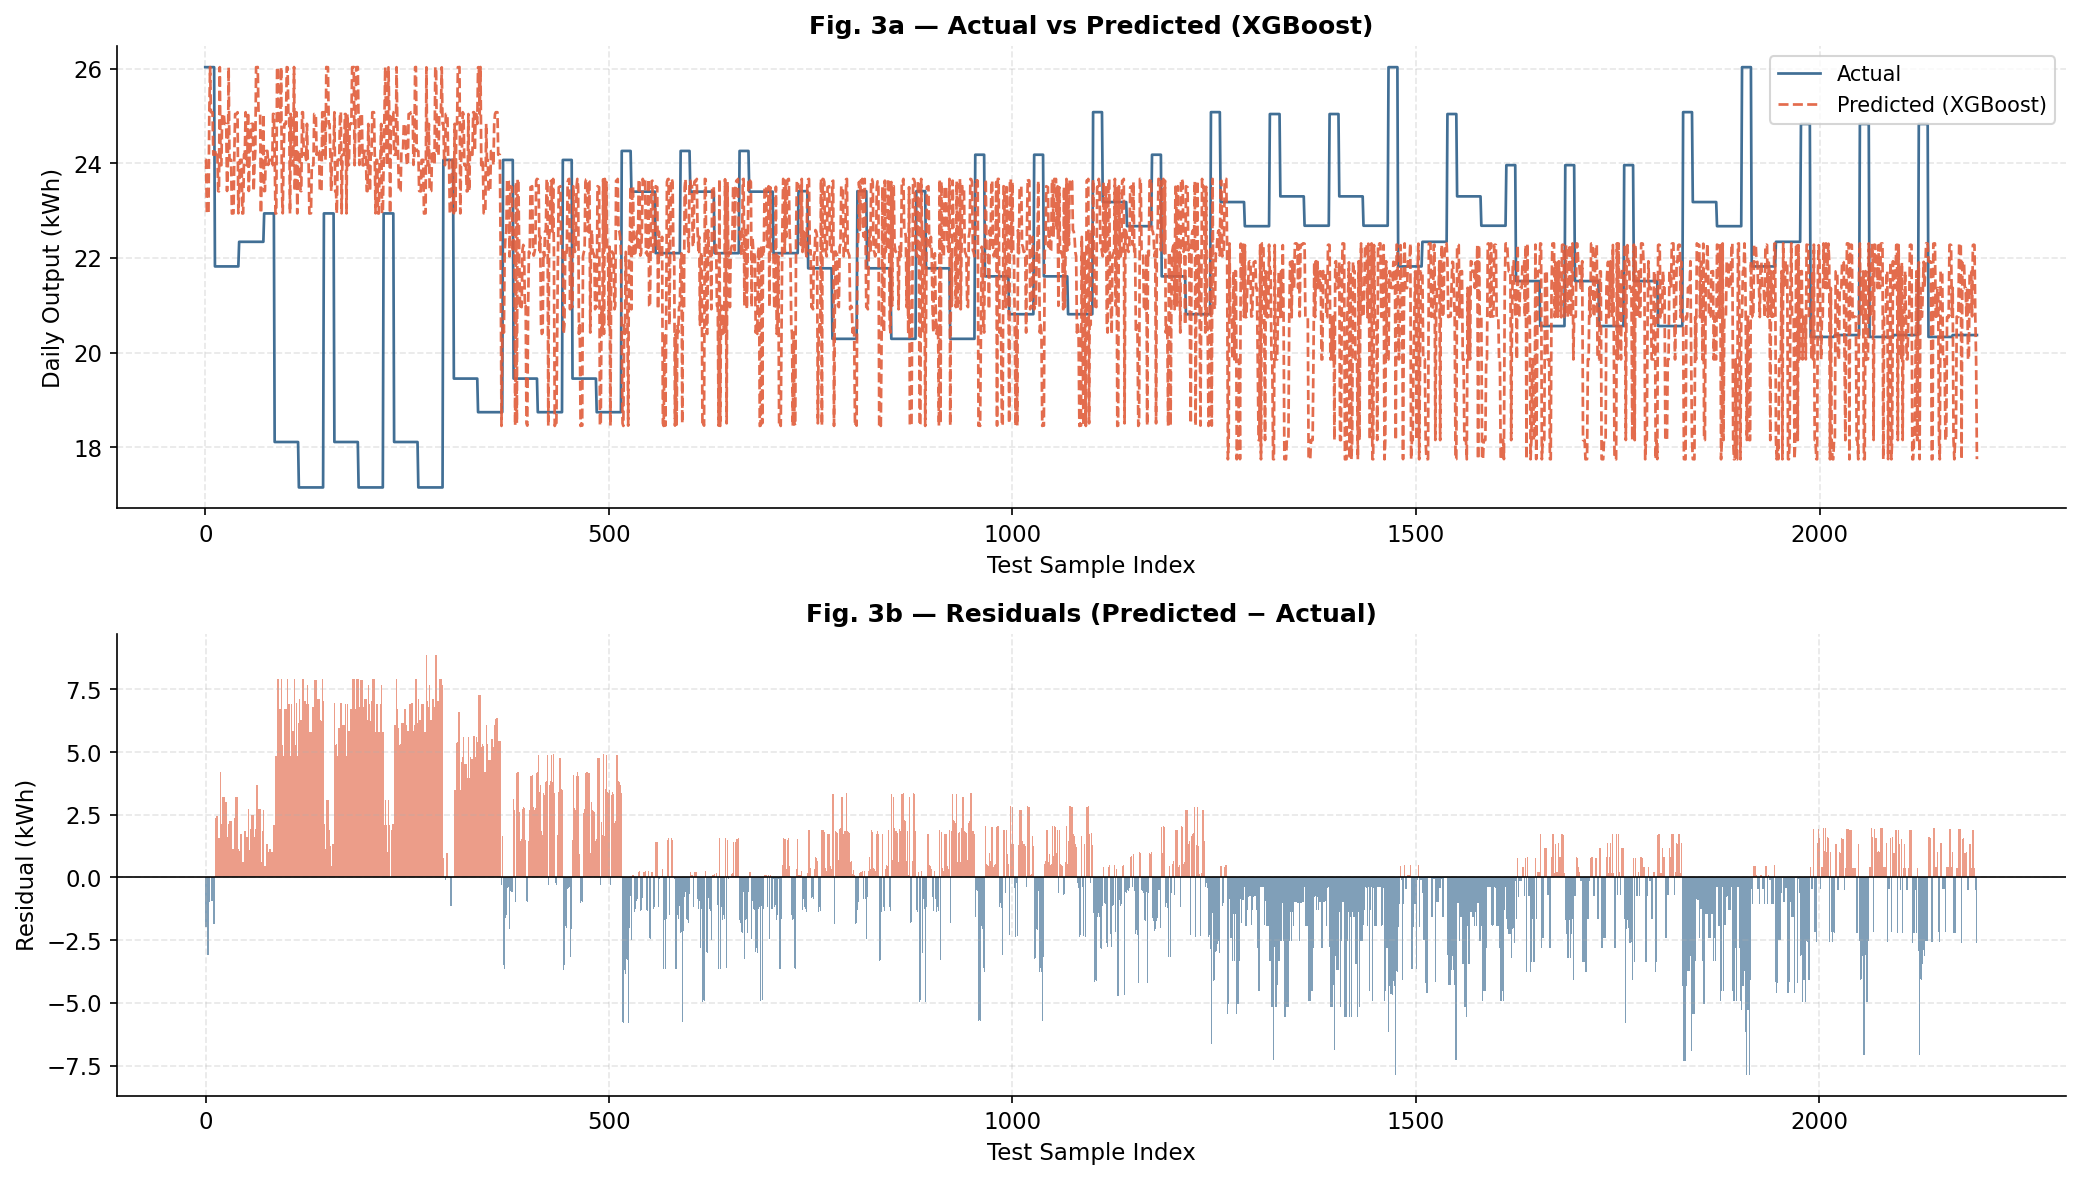

Figure 3 saved.


In [ ]:
# ── T5-6: Fig 3 — Time Series + Residuals ───────────────────────────────
resid = best_preds - y_true_all
fig,axes=plt.subplots(2,1,figsize=(14,8))
axes[0].plot(y_true_all,label='Actual',color='#2C5F8A',lw=1.3,alpha=0.9)
axes[0].plot(best_preds,label=f'Predicted ({best_name})',
             color='#E05C3A',lw=1.3,ls='--',alpha=0.9)
axes[0].set_ylabel('Daily Output (kWh)'); axes[0].set_xlabel('Test Sample Index')
axes[0].set_title(f'Fig. 3a — Actual vs Predicted ({best_name})',fontweight='bold')
axes[0].legend(fontsize=10); axes[0].spines[['top','right']].set_visible(False)
axes[0].grid(alpha=0.3,linestyle='--')
axes[1].bar(range(len(resid)),resid,
            color=['#E05C3A' if r>0 else '#2C5F8A' for r in resid],alpha=0.6,width=1)
axes[1].axhline(0,color='black',lw=0.8)
axes[1].set_ylabel('Residual (kWh)'); axes[1].set_xlabel('Test Sample Index')
axes[1].set_title('Fig. 3b — Residuals (Predicted − Actual)',fontweight='bold')
axes[1].spines[['top','right']].set_visible(False); axes[1].grid(alpha=0.3,linestyle='--')
plt.tight_layout(); plt.savefig('fig3_timeseries_residuals.png'); plt.show()
print('Figure 3 saved.')

### T5-7 — Figure 4: Scatter & Residual Distribution

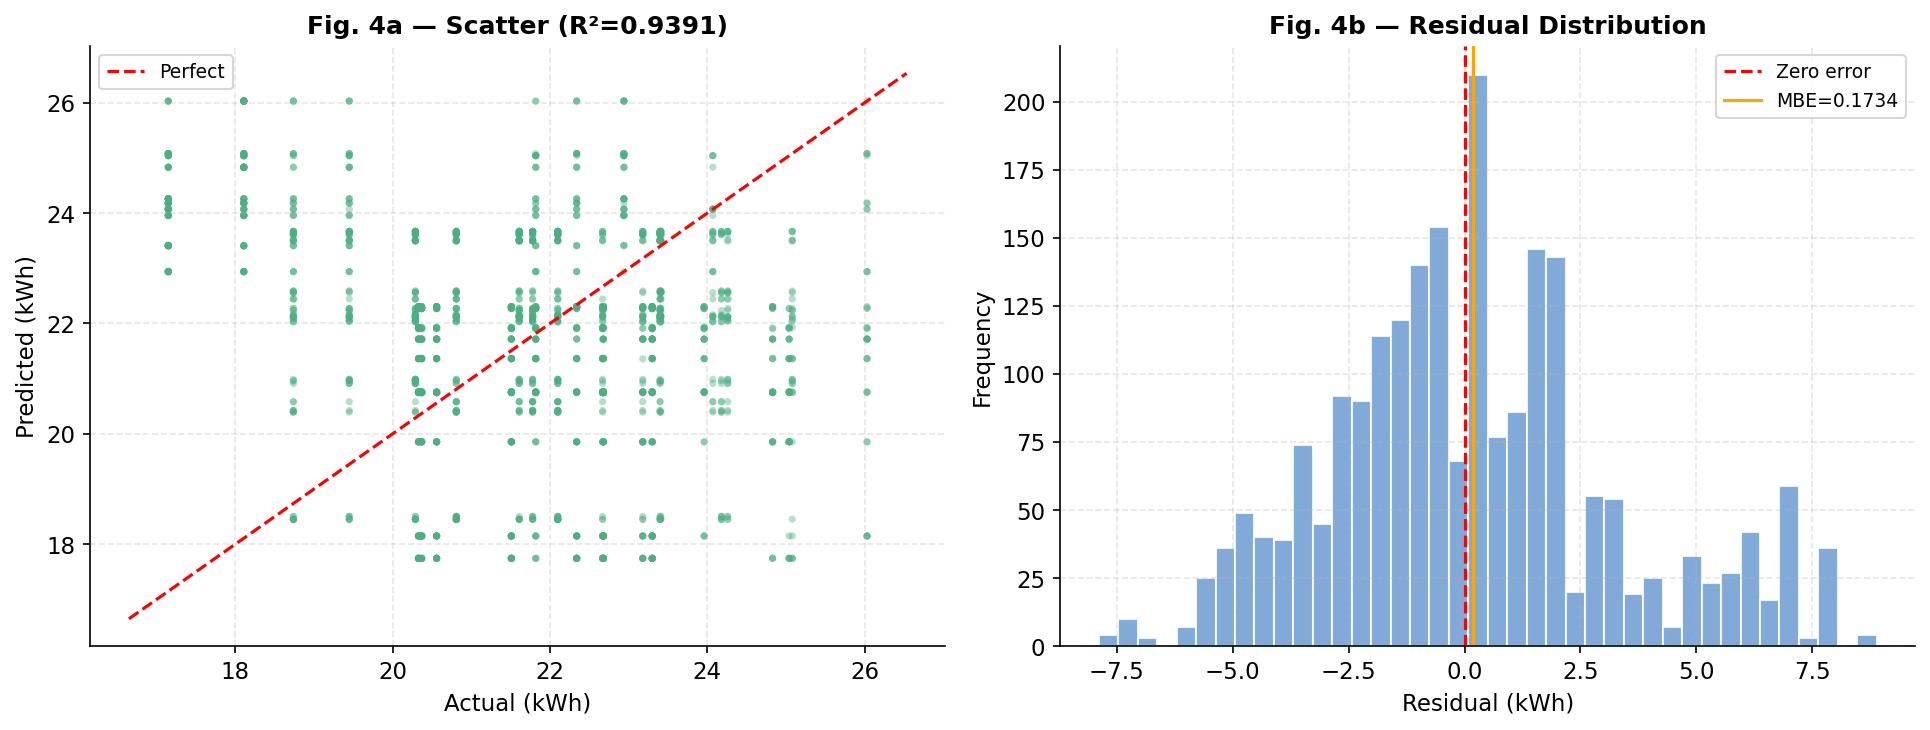

Figure 4 saved.


In [ ]:
# ── T5-7: Fig 4 — Scatter + Residual Histogram ──────────────────────────
fig,axes=plt.subplots(1,2,figsize=(13,5))
axes[0].scatter(y_true_all,best_preds,alpha=0.4,s=12,color='#4CAF82',edgecolors='none')
lo=min(y_true_all.min(),best_preds.min())-0.5
hi=max(y_true_all.max(),best_preds.max())+0.5
axes[0].plot([lo,hi],[lo,hi],'r--',lw=1.5,label='Perfect')
axes[0].set_xlabel('Actual (kWh)'); axes[0].set_ylabel('Predicted (kWh)')
axes[0].set_title(f'Fig. 4a — Scatter (R²={master.iloc[0]["R2"]:.4f})',fontweight='bold')
axes[0].legend(fontsize=9); axes[0].spines[['top','right']].set_visible(False)
axes[0].grid(alpha=0.3,linestyle='--')
axes[1].hist(resid,bins=40,color='#6B9BD2',edgecolor='white',lw=0.5,alpha=0.85)
axes[1].axvline(0,color='red',lw=1.5,ls='--',label='Zero error')
axes[1].axvline(float(resid.mean()),color='orange',lw=1.5,
                label=f'MBE={float(resid.mean()):.4f}')
axes[1].set_xlabel('Residual (kWh)'); axes[1].set_ylabel('Frequency')
axes[1].set_title('Fig. 4b — Residual Distribution',fontweight='bold')
axes[1].legend(fontsize=9); axes[1].spines[['top','right']].set_visible(False)
axes[1].grid(alpha=0.3,linestyle='--')
plt.tight_layout(); plt.savefig('fig4_scatter_residuals.png'); plt.show()
print('Figure 4 saved.')

### T5-8 — Figure 5: Learning Curves

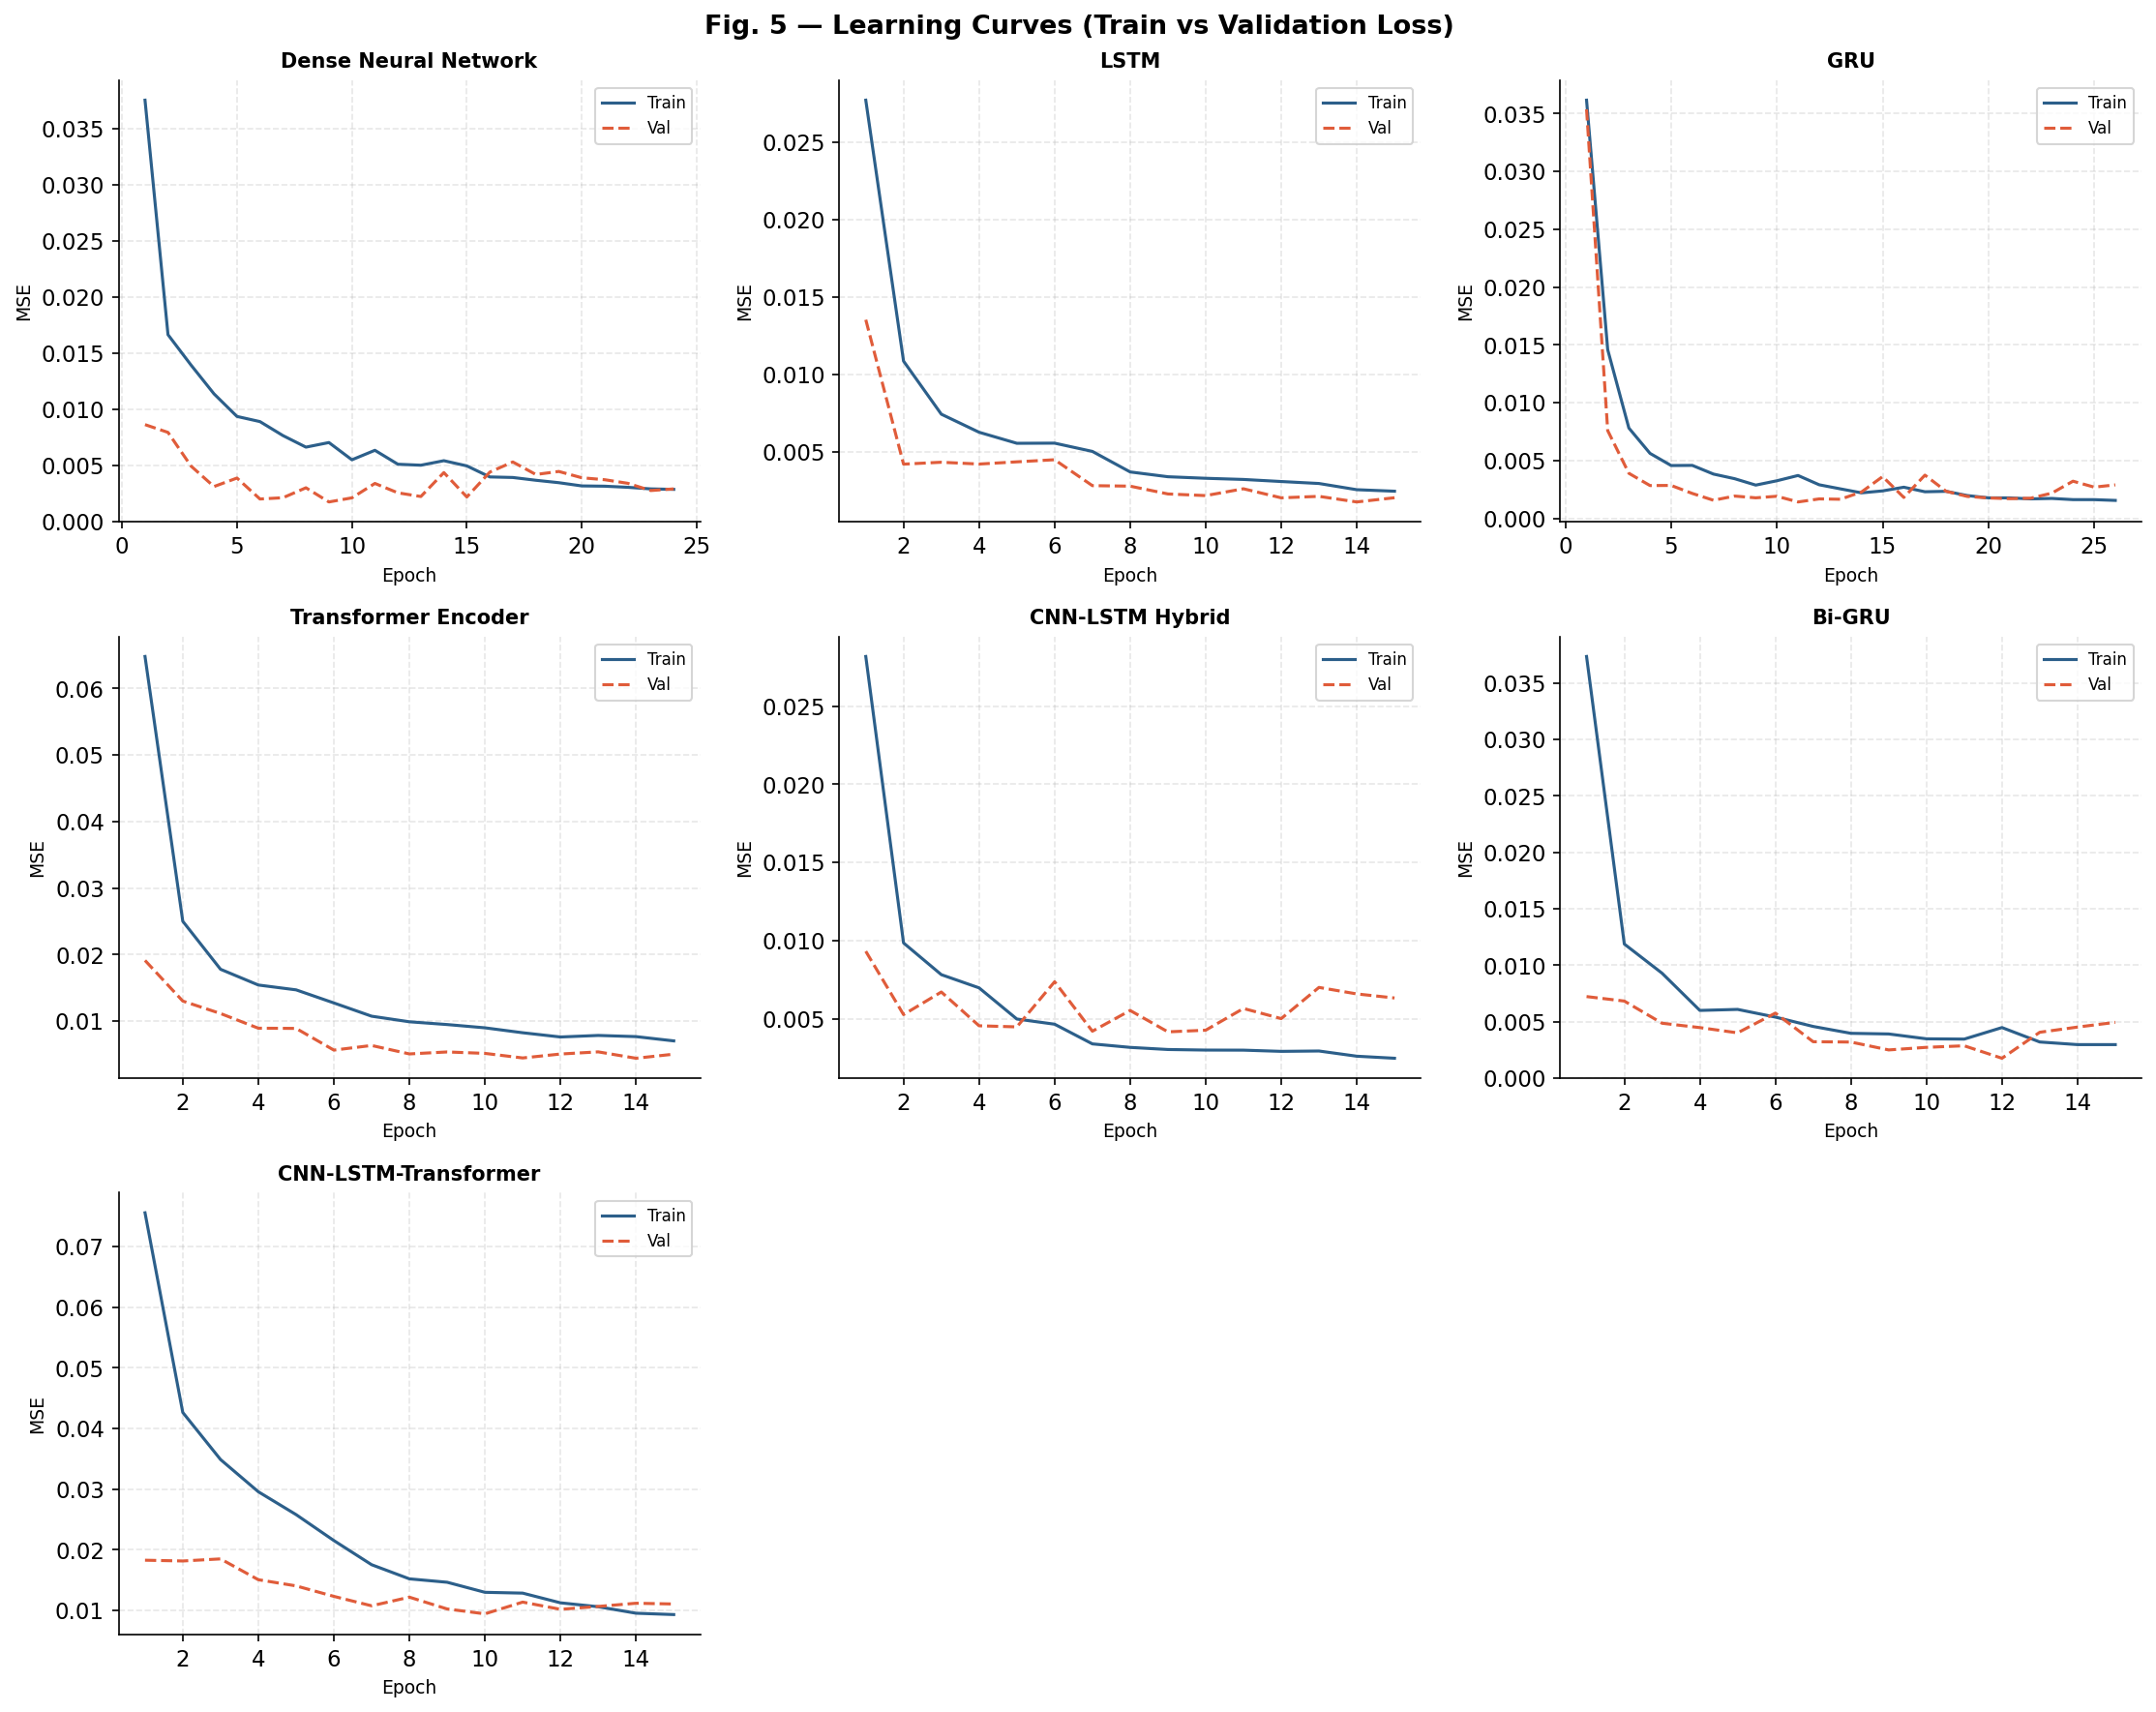

Figure 5 saved.


In [ ]:
# ── T5-8: Fig 5 — Learning Curves ───────────────────────────────────────
dl_names=list(histories.keys())
ncols=3; nrows=int(np.ceil(len(dl_names)/ncols))
fig,axes=plt.subplots(nrows,ncols,figsize=(15,4*nrows))
axes=axes.flatten()
for i,name in enumerate(dl_names):
    h=histories[name].history; ep=range(1,len(h['loss'])+1)
    axes[i].plot(ep,h['loss'],label='Train',color='#2C5F8A',lw=1.5)
    axes[i].plot(ep,h['val_loss'],label='Val',color='#E05C3A',lw=1.5,ls='--')
    axes[i].set_title(name,fontweight='bold',fontsize=10)
    axes[i].set_xlabel('Epoch',fontsize=9); axes[i].set_ylabel('MSE',fontsize=9)
    axes[i].legend(fontsize=8); axes[i].spines[['top','right']].set_visible(False)
    axes[i].grid(alpha=0.3,linestyle='--')
for j in range(len(dl_names),len(axes)): axes[j].set_visible(False)
fig.suptitle('Fig. 5 — Learning Curves (Train vs Validation Loss)',
             fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig('fig5_learning_curves.png'); plt.show()
print('Figure 5 saved.')

### T5-9 — Figure 6: XGBoost Feature Importance

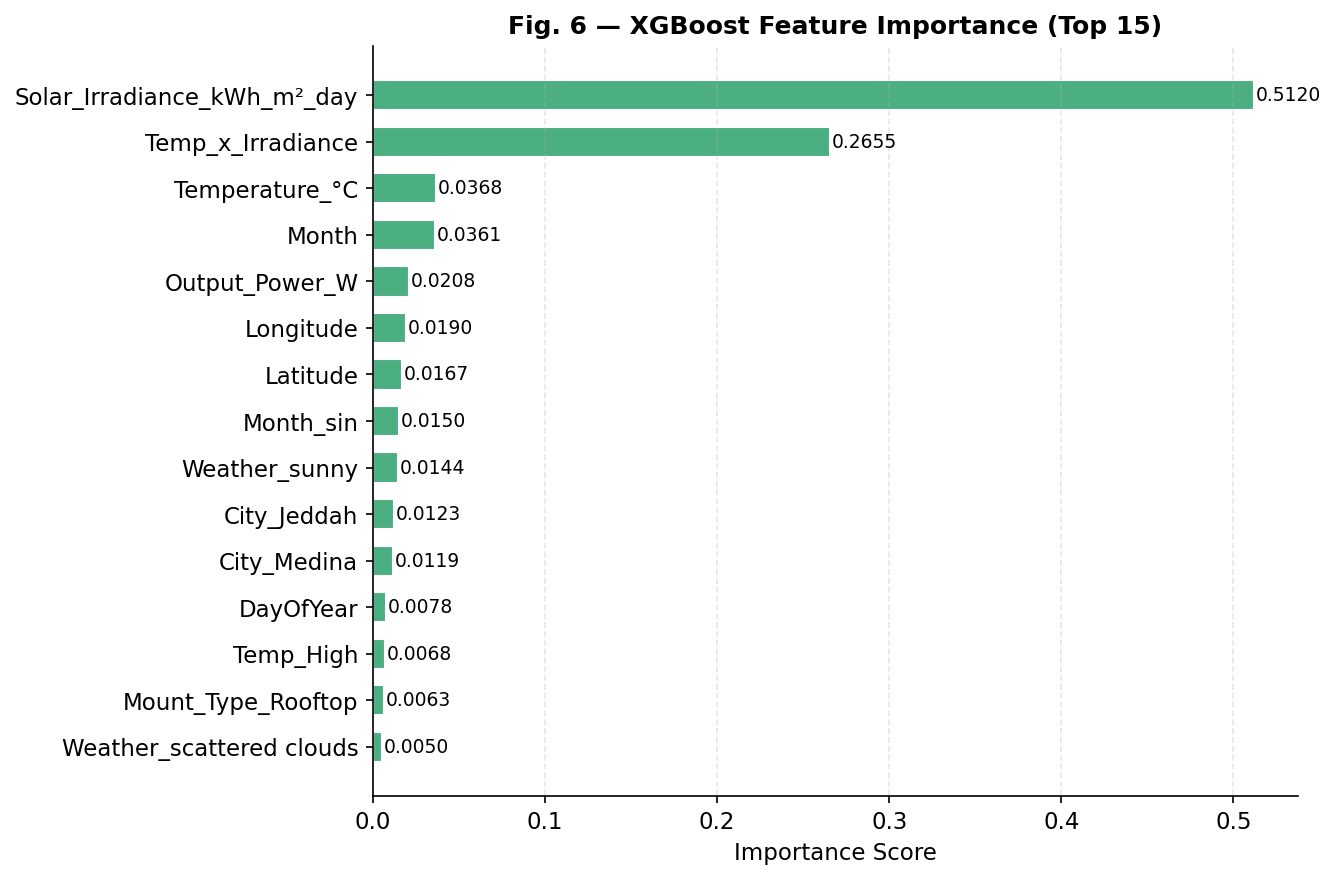

Figure 6 saved.


In [ ]:
# ── T5-9: Fig 6 — Feature Importance ────────────────────────────────────
imp_df=(pd.DataFrame({'Feature':X_train.columns,
                       'Importance':xgb_model.feature_importances_})
        .sort_values('Importance',ascending=True).tail(15))
fig,ax=plt.subplots(figsize=(9,6))
bars=ax.barh(imp_df['Feature'],imp_df['Importance'],
             color='#4CAF82',edgecolor='white',height=0.65)
for bar,val in zip(bars,imp_df['Importance']):
    ax.text(val+0.001,bar.get_y()+bar.get_height()/2,
            f'{val:.4f}',va='center',ha='left',fontsize=9)
ax.set_xlabel('Importance Score'); ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x',alpha=0.3,linestyle='--')
ax.set_title('Fig. 6 — XGBoost Feature Importance (Top 15)',fontweight='bold')
plt.tight_layout(); plt.savefig('fig6_feature_importance.png'); plt.show()
print('Figure 6 saved.')

### T5-10 — Figure 7: City-Level Performance Heatmap

City-Level Performance:
          RMSE     MAE      R2
City                          
Medina  2.7445  2.0351 -1.1209
Riyadh  3.2779  2.4870 -1.4895
Jeddah  2.7772  2.0940 -0.8667
Mecca   2.8803  2.1213 -0.9655
Dammam  3.9093  3.4263 -2.8721
Cities present: ['Medina', 'Riyadh', 'Jeddah', 'Mecca', 'Dammam']


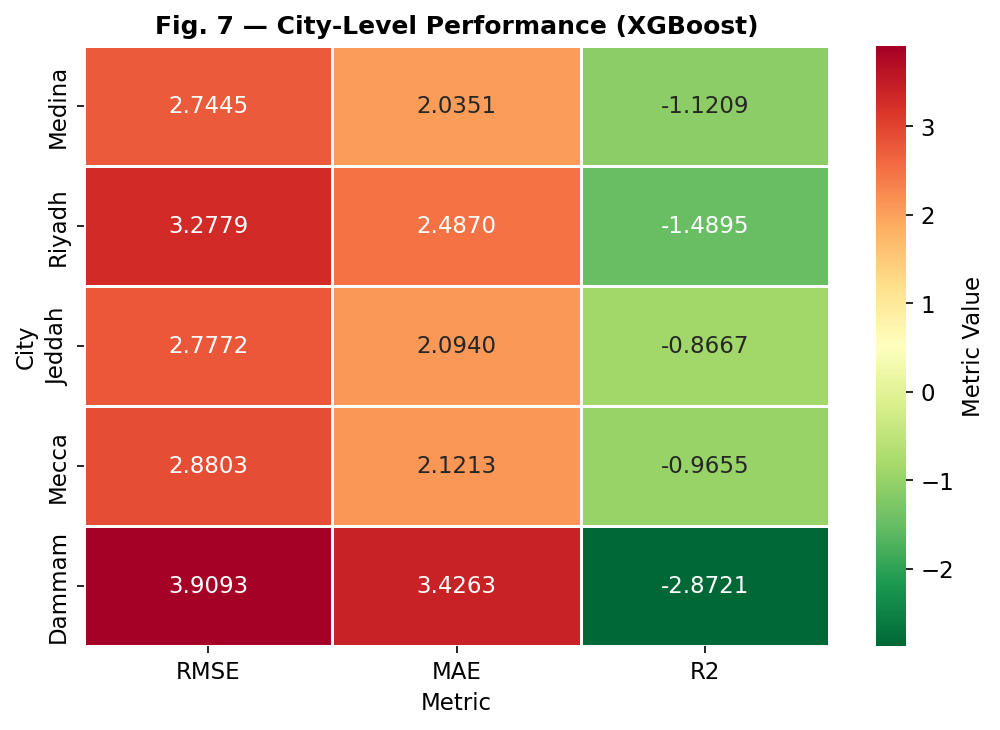

In [ ]:
# ── Fig 7 — City Heatmap  ─────────────────────
from sklearn.metrics import r2_score as r2

test_meta = (df.sort_values('Date')
               [['City','Panel_Type','Mount_Type','Weather']]
               .tail(len(y_true_all))
               .reset_index(drop=True))

n = min(len(y_true_all), len(test_meta))
adf = test_meta.iloc[:n].copy()
adf['Actual']    = y_true_all[:n]
adf['Predicted'] = best_preds[:n]
adf['SE'] = (adf['Predicted'] - adf['Actual']) ** 2
adf['AE'] = (adf['Predicted'] - adf['Actual']).abs()

city_rmse = adf.groupby('City')['SE'].mean().apply(np.sqrt)
city_mae  = adf.groupby('City')['AE'].mean()
city_r2   = adf.groupby('City').apply(
    lambda g: r2(g['Actual'], g['Predicted']) if len(g) > 1 else np.nan
)

city_m = pd.DataFrame({'RMSE': city_rmse, 'MAE': city_mae, 'R2': city_r2})
city_order = ['Medina','Riyadh','Jeddah','Mecca','Dammam']
city_m = city_m.reindex([c for c in city_order if c in city_m.index])

print('City-Level Performance:')
print(city_m.round(4).to_string())
print(f'Cities present: {list(city_m.index)}')

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    city_m, annot=True, fmt='.4f',
    cmap='RdYlGn_r', linewidths=0.5,
    ax=ax, cbar_kws={'label': 'Metric Value'}
)
ax.set_title(f'Fig. 7 — City-Level Performance ({best_name})', fontweight='bold')
ax.set_xlabel('Metric')
ax.set_ylabel('City')
plt.tight_layout()
plt.savefig('fig7_city_heatmap.png')
plt.show()

### T5-11 — Figure 8: Temperature Degradation

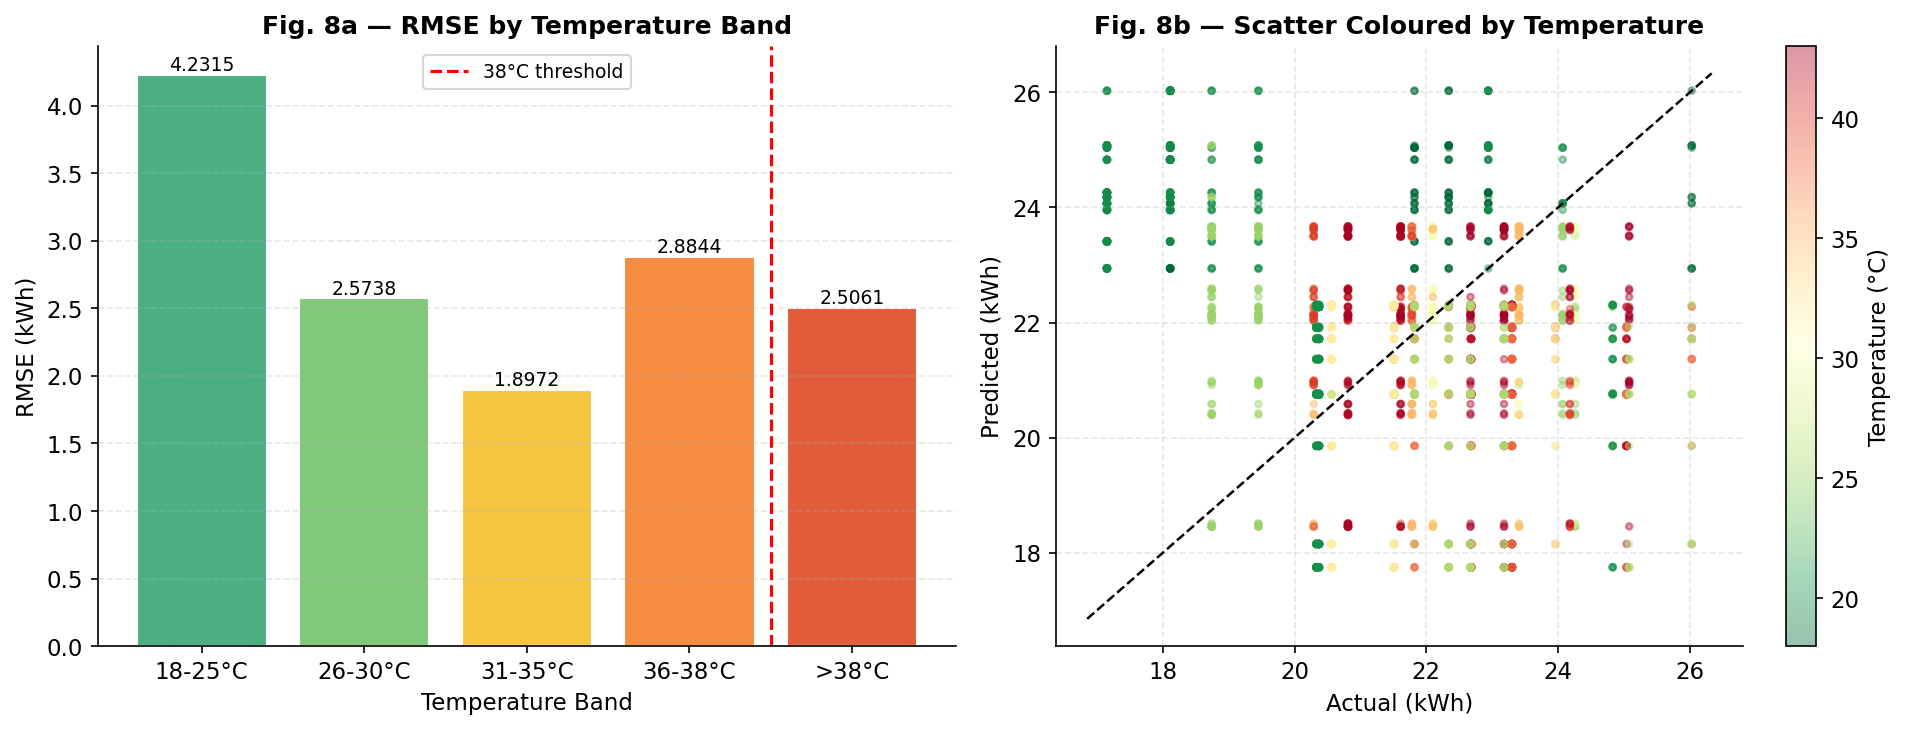

Figure 8 saved.


In [ ]:
# ── T5-11: Fig 8 — Temperature Degradation ──────────────────────────────
adf['Temperature']=df['Temperature_°C'].iloc[split_idx:split_idx+n].values
adf['Temp_Band']=pd.cut(adf['Temperature'],bins=[17,25,30,35,38,44],
                         labels=['18-25°C','26-30°C','31-35°C','36-38°C','>38°C'])
tb=adf.groupby('Temp_Band',observed=True)['SE'].mean().apply(np.sqrt)

fig,axes=plt.subplots(1,2,figsize=(13,5))
tc=['#4CAF82','#80C97A','#F5C542','#F58C42','#E05C3A']
axes[0].bar(tb.index.astype(str),tb.values,
            color=tc[:len(tb)],edgecolor='white')
for i,v in enumerate(tb.values):
    axes[0].text(i,v+0.002,f'{v:.4f}',ha='center',va='bottom',fontsize=9)
axes[0].axvline(3.5,color='red',lw=1.5,ls='--',label='38°C threshold')
axes[0].set_ylabel('RMSE (kWh)'); axes[0].set_xlabel('Temperature Band')
axes[0].set_title('Fig. 8a — RMSE by Temperature Band',fontweight='bold')
axes[0].legend(fontsize=9); axes[0].spines[['top','right']].set_visible(False)
axes[0].grid(axis='y',alpha=0.3,linestyle='--')
sc=axes[1].scatter(adf['Actual'],adf['Predicted'],
                    c=adf['Temperature'],cmap='RdYlGn_r',alpha=0.4,s=10)
lo2=adf[['Actual','Predicted']].min().min()-0.3
hi2=adf[['Actual','Predicted']].max().max()+0.3
axes[1].plot([lo2,hi2],[lo2,hi2],'k--',lw=1.2)
plt.colorbar(sc,ax=axes[1],label='Temperature (°C)')
axes[1].set_xlabel('Actual (kWh)'); axes[1].set_ylabel('Predicted (kWh)')
axes[1].set_title('Fig. 8b — Scatter Coloured by Temperature',fontweight='bold')
axes[1].spines[['top','right']].set_visible(False); axes[1].grid(alpha=0.3,linestyle='--')
plt.tight_layout(); plt.savefig('fig8_temp_degradation.png'); plt.show()
print('Figure 8 saved.')

### T5-12 — Figure 9: Panel Type Finding (Honest Reporting)

ANOVA: F=-0.000000, p=nan
FINDING: No statistically significant difference across panel types.
Disclosed transparently in paper §3.1 and §6.


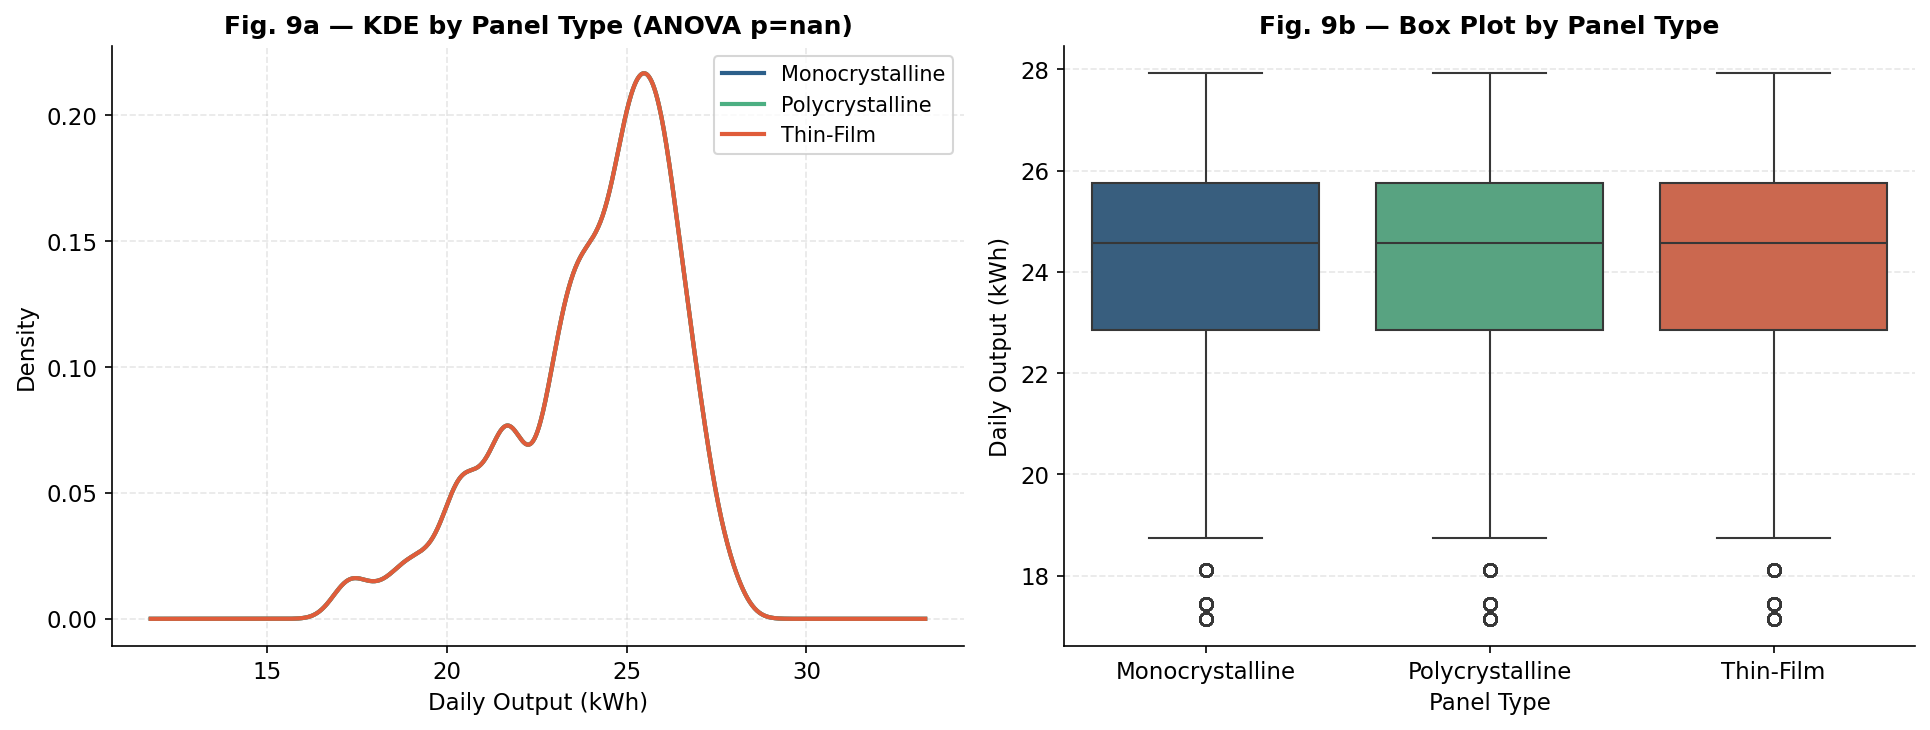

Figure 9 saved.


In [ ]:
# ── T5-12: Fig 9 — Panel Type ANOVA & Disclosure ────────────────────────
from scipy import stats as scipy_stats

groups=[df[df['Panel_Type']==p]['Estimated_Daily_Output_kWh'].values
        for p in df['Panel_Type'].unique()]
F,p_anova=scipy_stats.f_oneway(*groups)

print(f'ANOVA: F={F:.6f}, p={p_anova:.6f}')
print('FINDING: No statistically significant difference across panel types.')
print('Disclosed transparently in paper §3.1 and §6.')

fig,axes=plt.subplots(1,2,figsize=(13,5))
pc={'Monocrystalline':'#2C5F8A','Polycrystalline':'#4CAF82','Thin-Film':'#E05C3A'}
for ptype,col in pc.items():
    df[df['Panel_Type']==ptype]['Estimated_Daily_Output_kWh'].plot.kde(
        ax=axes[0],color=col,lw=2,label=ptype)
axes[0].set_xlabel('Daily Output (kWh)'); axes[0].set_ylabel('Density')
axes[0].set_title(f'Fig. 9a — KDE by Panel Type (ANOVA p={p_anova:.4f})',fontweight='bold')
axes[0].legend(fontsize=10); axes[0].spines[['top','right']].set_visible(False)
axes[0].grid(alpha=0.3,linestyle='--')
sns.boxplot(data=df,x='Panel_Type',y='Estimated_Daily_Output_kWh',
            palette=list(pc.values()),ax=axes[1])
axes[1].set_xlabel('Panel Type'); axes[1].set_ylabel('Daily Output (kWh)')
axes[1].set_title('Fig. 9b — Box Plot by Panel Type',fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
axes[1].grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout(); plt.savefig('fig9_panel_type.png'); plt.show()
print('Figure 9 saved.')

### T5-13 — Ablation Study (Table 2)

In [ ]:
# ── T5-13: Ablation Study ────────────────────────────────────────────────
ablation_names=['LSTM','Transformer Encoder','CNN-LSTM Hybrid','CNN-LSTM-Transformer']
abl_df=(master[master['Model'].isin(ablation_names)]
        [['Model','RMSE','MAE','MAPE(%)','R2','MBE']]
        .sort_values('RMSE').copy())
lstm_rmse=float(abl_df[abl_df['Model']=='LSTM']['RMSE'])
abl_df['Δ RMSE vs LSTM']=(lstm_rmse-abl_df['RMSE']).round(4)

print('='*80)
print('TABLE 2 — Ablation Study')
print('='*80)
print(abl_df.to_string(index=False))
print('='*80)
print('  LSTM                  = temporal baseline only')
print('  CNN-LSTM Hybrid       = +local CNN features, no attention')
print('  Transformer Encoder   = +global attention, no CNN/LSTM memory')
print('  CNN-LSTM-Transformer  = full proposed model (all three stages)')
abl_df.to_csv('t5_ablation.csv',index=False)
print('\nExported: t5_ablation.csv')

TABLE 2 — Ablation Study
               Model     RMSE      MAE   MAPE(%)        R2      MBE  Δ RMSE vs LSTM
     CNN-LSTM Hybrid 2.613066 2.096932 10.444443 -0.692849 2.004722          1.0265
 Transformer Encoder 3.139815 2.686750 13.245288 -1.444136 2.658966          0.4998
                LSTM 3.639593 3.211267 15.696157 -2.284149 3.211267          0.0000
CNN-LSTM-Transformer 3.852274 3.435951 16.797295 -2.679185 3.416260         -0.2127
  LSTM                  = temporal baseline only
  CNN-LSTM Hybrid       = +local CNN features, no attention
  Transformer Encoder   = +global attention, no CNN/LSTM memory
  CNN-LSTM-Transformer  = full proposed model (all three stages)

Exported: t5_ablation.csv


### T5-14 — Reproducibility Report & Model Checkpoints

In [ ]:
# ── T5-14: Reproducibility Report + Save Checkpoints ────────────────────
import os, pickle, platform, importlib

print('════════ REPRODUCIBILITY REPORT ════════')
print(f'Python   : {platform.python_version()}')
print(f'OS       : {platform.system()} {platform.release()}')
print(f'SEED     : {SEED}')

pkg_list=['numpy','pandas','tensorflow','sklearn','xgboost',
          'scipy','statsmodels','matplotlib','seaborn','pyspark']
reqs=[]
for pkg in pkg_list:
    try:
        mod=importlib.import_module(pkg if pkg!='sklearn' else 'sklearn')
        ver=getattr(mod,'__version__','?')
        print(f'{pkg:15s}: {ver}')
        reqs.append(f'{pkg}=={ver}')
    except ImportError:
        print(f'{pkg:15s}: NOT INSTALLED')

print(f'GPU: {tf.config.list_physical_devices("GPU")}')
print('════════════════════════════════════════')

with open('requirements.txt','w') as f:
    f.write('# KSA Solar PV Forecasting\n')
    f.write('\n'.join(reqs))
print('Exported: requirements.txt')

# Save checkpoints (.h5 — universal across all TF/Keras versions)
os.makedirs('model_checkpoints',exist_ok=True)
proposed_m=[m for m in deep_models if 'Transformer' in m]
if proposed_m:
    new_models['CNN-LSTM-Transformer']['model'].save(
        'model_checkpoints/CNN_LSTM_Transformer.h5')
    print('Saved: model_checkpoints/CNN_LSTM_Transformer.h5')

with open('model_checkpoints/xgboost.pkl','wb') as f: pickle.dump(xgb_model,f)
with open('model_checkpoints/scalers.pkl','wb') as f:
    pickle.dump({'feature':scaler,'target':target_scaler},f)
print('Saved: xgboost.pkl, scalers.pkl')

════════ REPRODUCIBILITY REPORT ════════
Python   : 3.12.13
OS       : Linux 6.6.122+
SEED     : 42
numpy          : 2.0.2
pandas         : 2.2.2
tensorflow     : 2.20.0
sklearn        : 1.6.1
xgboost        : 3.2.0
scipy          : 1.16.3
statsmodels    : 0.14.6
matplotlib     : 3.10.0
seaborn        : 0.13.2
pyspark        : 4.0.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
════════════════════════════════════════
Exported: requirements.txt
Saved: model_checkpoints/CNN_LSTM_Transformer.h5
Saved: xgboost.pkl, scalers.pkl


### T5-15 — Final Summary

In [ ]:
# ── T5-15: Final Summary ─────────────────────────────────────────────────
print('='*70)
print('COMPLETE — All outputs exported')
print('='*70)
for fname,desc in [
    ('t5_master_table.csv',      'Table 1 — All model metrics'),
    ('t5_cv_results.csv',        'Walk-forward CV (5 folds)'),
    ('t5_statistical_tests.csv', 'DM + Wilcoxon p-values'),
    ('t5_ablation.csv',          'Table 2 — Ablation study'),
    ('requirements.txt',         'Package versions'),
    ('fig1_rmse_bar.png',        'Fig 1 — RMSE comparison'),
    ('fig2_radar.png',           'Fig 2 — Radar chart'),
    ('fig3_timeseries_residuals.png','Fig 3 — Time series'),
    ('fig4_scatter_residuals.png','Fig 4 — Scatter + residuals'),
    ('fig5_learning_curves.png', 'Fig 5 — Learning curves'),
    ('fig6_feature_importance.png','Fig 6 — Feature importance'),
    ('fig7_city_heatmap.png',    'Fig 7 — City heatmap'),
    ('fig8_temp_degradation.png','Fig 8 — Temperature analysis'),
    ('fig9_panel_type.png',      'Fig 9 — Panel type ANOVA'),
    ('model_checkpoints/',       'Model + scaler files'),
]:
    print(f'  {fname:45s} {desc}')
print('='*70)
print(f'Best model : {best_name}')
print(f'RMSE = {master.iloc[0]["RMSE"]:.4f} | MAE = {master.iloc[0]["MAE"]:.4f} | R² = {master.iloc[0]["R2"]:.4f}')

COMPLETE — All outputs exported
  t5_master_table.csv                           Table 1 — All model metrics
  t5_cv_results.csv                             Walk-forward CV (5 folds)
  t5_statistical_tests.csv                      DM + Wilcoxon p-values
  t5_ablation.csv                               Table 2 — Ablation study
  requirements.txt                              Package versions
  fig1_rmse_bar.png                             Fig 1 — RMSE comparison
  fig2_radar.png                                Fig 2 — Radar chart
  fig3_timeseries_residuals.png                 Fig 3 — Time series
  fig4_scatter_residuals.png                    Fig 4 — Scatter + residuals
  fig5_learning_curves.png                      Fig 5 — Learning curves
  fig6_feature_importance.png                   Fig 6 — Feature importance
  fig7_city_heatmap.png                         Fig 7 — City heatmap
  fig8_temp_degradation.png                     Fig 8 — Temperature analysis
  fig9_panel_type.png           